# Release candidate: 2-day rebalance, 33% concentration, 10 BPS exit fee

**This notebook is the current release candidate for the Hyperliquid vault-of-vaults strategy.**
It supersedes `36-backtest-gated-inverse-vol-max6.ipynb` and `53-backtest-nb36-max-concentration-35pct.ipynb`
as the configuration to take forward to live trading, and it is the reference other notebooks in
this chain should be compared against.

Its claim to that status rests on three things: it is the only notebook in the chain that runs
entirely on daily-resolution price data, it charges the 10 BPS redemption fee that live vault exits
will actually pay, and it reproduces the NB63/NB64 optimiser result to within 0.36 pp while using a
native 2-day engine cycle rather than a clock trick.

**Candidate parameters**: 2-day cadence, 6-vault basket, 33% concentration ceiling, 15% pool cap,
$5 sell-side softband, no minimum hold, composite CAGR+Sharpe selection, 14-day momentum gate,
60-day inverse-vol sizing. See "What to do about it" for the two open defects that gate promotion.

Based on `59-backtest-nb36-vault-redemption-fee-10bps.ipynb`, which is
`36-backtest-gated-inverse-vol-max6.ipynb` plus a 10 BPS vault redemption fee. Four changes:

1. **A native 2-day decision cycle.** `cycle_duration = CycleDuration.cycle_2d`, passed straight to
   `run_backtest_inline()`. No sub-daily clock and no modulo counter in `decide_trades` - the engine
   steps every 48 hours, and the notebook asserts the realised cycle spacing to prove it.
2. **33% concentration ceiling**, against NB36's 50% and NB63/NB64's 35%.
3. **Window starts 2026-01-01**, matching NB63/NB64, against NB36's 2025-08-01.
4. **Fee drag mitigation**: the sell-side softband widened from the $5 floor to **$125** (0.5% of
   the $25,000 bankroll). $250 scored best in NB63/NB64 but crashed the backtest on NB36's window.

Everything else is the NB36 release candidate untouched: 6-vault basket, 15% pool cap, composite
CAGR+Sharpe selection, 14-day momentum gate, 60-day inverse-vol sizing. `minimum_hold_days` is
deliberately absent - NB63 and NB64 both found it inert at or below the cadence and harmful above it.

## Why the window moved

The Hypercore share-price feed is sampled **weekly until 2026-01-17** and daily afterwards. Over
NB36's 344-day window that leaves 140 of 338 days with no observation for any vault (41%), which
`load_partial_data()` forward-fills. A cadence experiment cannot run on that: daily and 2-day
rebalancing both act on the same stale number, and multi-day moves land as a single print when the
feed resumes.

Starting at 2026-01-01 keeps only the fortnight of partial coverage - January 2026 is 55% covered -
and the notebook re-runs the whole factorial from 2026-01-17, where coverage is unbroken, so the
dependence on that fortnight is measured rather than assumed.

## Structure

- 2x3 factorial at 10 BPS: {daily, 2-day} x {$5, $125, $250 softband}, crashes recorded rather than
  fatal
- 0 BPS reference at the headline configuration
- Vault price data coverage measured from the raw parquet, filtered to the traded vault addresses
- The factorial repeated on the daily-resolution sub-window
- Concentration and window sensitivity, reconciled against NB63/NB64

## Key new insights and what did we learn from this experiment?

### The 2-day cadence is worth +16.5 pp of CAGR here, and it improves drawdown at the same time

Full window, 10 BPS, 33% concentration:

| Configuration | Final equity | CAGR | Sharpe | Max DD | Trades | Turnover | Fee paid |
|---|---:|---:|---:|---:|---:|---:|---:|
| Daily, $5 band | $27,090 | 17.00% | 0.95 | -7.65% | 858 | 16.2x | $404 |
| Daily, $125 band | $27,090 | 17.00% | 0.95 | -7.65% | 629 | 16.0x | $400 |
| Daily, $250 band | $27,158 | 17.56% | 0.97 | -7.69% | 568 | 15.9x | $397 |
| **2-day, $5 band** | **$29,005** | **33.70%** | **1.72** | **-5.60%** | 511 | 12.4x | $309 |
| 2-day, $125 band (this notebook) | $28,982 | 33.49% | 1.70 | -5.60% | 420 | 12.3x | $307 |
| 2-day, $250 band | $29,060 | 34.19% | 1.73 | -5.65% | 388 | 12.2x | $306 |

The cadence marginal is **+16.50 to +16.70 pp of CAGR** at every softband level, with drawdown
**2.05 pp better** and 347 fewer trades. Sharpe roughly doubles, 0.95 -> 1.72.

**The effect is much larger at a 33% cap than at 50%.** An earlier revision of this notebook, run at
NB36's 50% ceiling, measured the same cadence change at +5.91 pp. Tightening concentration and
slowing the cadence are not independent: a tight cap spreads capital across more vaults, and a
slower cadence stops churning that allocation.

### It is still not a fee saving

| | Value |
|---|---:|
| CAGR change, daily/$5 -> 2-day/$125 | **+16.50 pp** |
| Fee saved | **$97** = 0.74%/yr of capital |
| Share of the CAGR change explained by the fee saving | **5%** |

Third measurement of the same ratio: NB64 found 5%, NB65 at a 50% cap found 8%, this run finds 5%.
The 2-day cadence earns its keep by holding through short-term noise - 83 positions and 77 exits
become 70 and 64 - not by paying less fee. Total 10 BPS drag is **2.43%/yr** and the levers recover
under a third of it.

### The softband still does nothing, and $250 no longer crashes only because the window moved

| Softband change | CAGR delta | Trade delta | Fee saved |
|---|---:|---:|---:|
| $5 -> $125, daily | -0.00% | -229 | $5 |
| $5 -> $125, 2-day | -0.21% | -91 | $2 |
| $5 -> $250, daily | +0.57% | -290 | $8 |
| $5 -> $250, 2-day | +0.49% | -123 | $3 |

All six cells complete on this window - the `OutOfSimulatedBalance` crash that killed both $250
configurations happened on **2025-08-12**, which is now outside the backtest. **The underlying defect
is not fixed**: suppressed sells are not deducted from the buy budget, so a wide band can still
commit proceeds from a trim it then cancels. $250 looking safe here is a property of the window, not
of the code, which is why the headline configuration stays at $125 despite $250 scoring marginally
better.

### Concentration: 33% and 35% are the same, 50% is not

| Concentration | CAGR | Sharpe | Max DD |
|---:|---:|---:|---:|
| 33% (this notebook) | 33.70% | 1.72 | -5.60% |
| 35% (NB63/NB64) | 33.81% | 1.75 | -5.90% |
| 50% (NB36) | 28.79% | 1.70 | -6.07% |

33% -> 35% is **+0.11 pp**, i.e. indistinguishable; 33% -> 50% is **-4.91 pp**. The axis is flat
between a third and 35% and steep beyond it, so there is nothing to gain from tuning inside that
range.

### This notebook reproduces NB64

At a matched 35% cap this notebook returns **33.81%** against NB64's **33.45%** for its 48h / hold 1
/ $5 cell on the same window - a **+0.36 pp** residual covering the only two remaining differences:
the dataset vintage (shared cache re-downloaded 2026-08-08 17:33, 143 KB larger than the frozen
`hl-min-1000` copy) and the cadence mechanism (native `cycle_2d` here against NB64's 2h clock with a
modulo counter). **Those two together are worth a third of a percentage point**, which retires the
concern that NB64's clock trick was doing something the parameter did not describe.

## Summary of results

Headline: **2-day cadence, 33% concentration, $125 softband, 10 BPS fee, 2026-01-01 to 2026-07-10.**

Note the **release candidate ships the $5 softband**, not the $125 used for this notebook's headline
run: the softband is worth nothing on either window (-0.21 pp at 2-day cadence) and the wide-band
code path has an unfixed defect. The $125 and $5 rows differ by 0.21 pp of CAGR, so the headline
numbers below are representative of the candidate either way.

| Metric | This notebook | Daily-cadence control |
|---|---:|---:|
| Final equity | **$28,982** | $27,090 |
| Cumulative return | **15.93%** | 8.36% |
| CAGR | **33.49%** | 17.00% |
| Sharpe | **1.70** | 0.95 |
| Sortino | **2.44** | 1.29 |
| Max drawdown | **-5.60%** | -7.65% |
| Positions / trades | 70 / 420 | 83 / 858 |
| Redemption turnover | **12.3x** | 16.2x |
| Fee paid | **$307** | $404 |

Fee A/B at the headline configuration: **$29,349 at 0 BPS against $28,982 at 10 BPS** - a drag of
-1.25% of final equity, **-2.43%/yr**, against $307 accounted. Median implied fee 0.100% against a
configured 0.100%.

On the daily-resolution sub-window (2026-01-17 onwards) the same configuration returns **28.35%
CAGR at -5.62% drawdown, Sharpe 1.47**, and the cadence effect is **+17.24 pp**.

## Robustness of results

- **Metrics are annualised on a daily grid, not on the strategy's cycle grid.** The equity curve is
  sampled once per cycle, so a 2-day cadence yields one observation every 48 hours; annualising that
  with `periods=365` overstates Sharpe and Sortino by `sqrt(2)` and made the 2-day configurations
  look better than the daily ones by construction. An earlier revision reported 2.41 where the
  correct figure is 1.70. `summarise_run()` now resamples to daily first.
- **The drawdown comparison still favours the slower cadence.** A 2-day schedule values the
  portfolio 95 times over the window against the daily schedule's 190, so it cannot observe a trough
  that opens and closes inside one of its own cycles. Part of the -5.60% against -7.65% is that
  blindness rather than genuine risk reduction. The CAGR comparison is unaffected.
- **The best step is a market move, not a lucky trade.** The largest step is +3.27% into
  2026-07-04, 6.8% of all positive return. Over that 2-day span Realist Ca gained 4.02%, Scared Mon
  3.79% and Mad Scient 3.68% while BTC rose 2.6% and ETH 4.7% - a broad basket move on a broad
  market move. Attribution had to be measured over the **step**, not the calendar day: comparing
  against the previous day's close showed every holding flat or down while the portfolio jumped,
  because the step spans two days.
- **Return is concentrated.** Neutralising the largest 5% of profitable days - three days - cuts
  CAGR from 33.49% to 11.62%. Excess kurtosis is 11.11 and skew is -0.98.
- **The maximum drawdown is essentially one step**: -5.30% on 2026-04-11 against a -5.60% maximum.
  That day is *not* explained by the market (BTC +0.11%, ETH +1.78%), so it is idiosyncratic to the
  basket and worth a look before sizing on this drawdown.
- **The window still contains a fortnight of partial data.** January 2026 is 55% covered; the feed
  only becomes reliably daily on 2026-01-17. Starting there instead costs **-5.09 pp of CAGR**,
  which is a large sensitivity to 16 days and a reminder that the opening fortnight trades partly on
  forward-filled prices. Everything from 2026-02 onwards is 100% covered.
- **The cadence result has never been measured on a disjoint period.** NB63, NB64 and this notebook
  all sit inside January-July 2026, because that is the only stretch with daily Hypercore data. The
  result replicates across concentration ceilings, engine mechanisms and dataset vintages, but not
  across time.
- **The 2-day cycle is verified, not assumed**: 95 cycles at exactly 48-hour spacing, asserted in
  the backtest cell.

## What to do about it

1. **Adopt the 2-day cadence at a 33-35% concentration ceiling.** It is worth +16.5 pp of CAGR and
   2 pp of drawdown here, and it reproduces NB64 to within a third of a point.
2. **Do not credit it as fee mitigation.** 5% of the gain is fee saving. If 10 BPS exits are the
   binding constraint, the answer is fewer full exits, not a slower clock.
3. **Leave the softband at the $5 floor** until the buy-sizing defect is fixed. $250 wins by half a
   point on this window and crashes on a longer one.
4. **Fix the softband/buy-budget interaction in the engine.** It has now caused a crash in NB65 and
   silently distorted the rankings in NB63 and NB64.
5. **Treat the -5.60% drawdown as a floor, not an estimate**, given the 2-day valuation grid and the
   single idiosyncratic -5.30% step inside it.


## Notebook setup

- Shared imports, chart output settings, and notebook logging for the clean-up variant.

In [1]:
import datetime
import logging

import pandas as pd
import plotly.express as px
from IPython.display import display

from tradingstrategy.client import Client
from tradeexecutor.utils.notebook import setup_charting_and_output, OutputMode

client = Client.create_jupyter_client()
setup_charting_and_output(OutputMode.static, image_format='png', width=1500, height=1000)
logger = logging.getLogger('strategy')

Started Trading Strategy in Jupyter notebook environment, configuration is stored in /Users/moo/.tradingstrategy


## Universe definition

- Use the same Hyperliquid survivor-first vault universe as NB152 so the clean-up stays directly comparable.

In [2]:
from eth_defi.token import USDC_NATIVE_TOKEN
from tradingstrategy.chain import ChainId
from tradeexecutor.state.identifier import AssetIdentifier

CHAIN_ID = ChainId.hyperliquid

EXCHANGES = ('uniswap-v2', 'uniswap-v3')
SUPPORTING_PAIRS = [
    (ChainId.arbitrum, 'uniswap-v3', 'WETH', 'USDC', 0.0005),
    (ChainId.ethereum, 'uniswap-v3', 'WETH', 'USDC', 0.0005),
    (ChainId.ethereum, 'uniswap-v3', 'WBTC', 'USDC', 0.003),
]
LENDING_RESERVES = None
PREFERRED_STABLECOIN = AssetIdentifier(
    chain_id=ChainId.hyperliquid.value,
    address=USDC_NATIVE_TOKEN[ChainId.hyperliquid].lower(),
    token_symbol='USDC',
    decimals=6,
)
ALLOWED_VAULT_DENOMINATION_TOKENS = {'USDC', 'USDT', 'USDC.e', 'crvUSD', 'USDT0', 'USD₮0', 'USDt', 'USDS'}

print(f'Chain universe: {CHAIN_ID.get_name()}')
print(f'Reserve asset: {PREFERRED_STABLECOIN}')


Chain universe: HyperEVM
Reserve asset: <USDC at 0xb88339cb7199b77e23db6e890353e22632ba630f>


## Parameters

- Keep the strategy parameters identical to `02-backtest-until-2026-07-09.ipynb`, except reduce initial capital to `25,000 USD`.


In [3]:
from tradeexecutor.strategy.cycle import CycleDuration
from tradeexecutor.strategy.default_routing_options import TradeRouting
from tradeexecutor.strategy.parameters import StrategyParameters
from tradingstrategy.timebucket import TimeBucket


class Parameters:
    #: Notebook identifier.
    id = '65-candidate-backtest-2d-cadence-fee-drag-mitigation'

    #: Daily candles match the whole Hyperliquid survivor-first research chain.
    candle_time_bucket = TimeBucket.d1
    #: Two-day rebalance cadence, the NB63/NB64 recommendation, expressed natively: the engine
    #: steps every 48 hours. NB64 reached the same schedule by running a sub-daily clock and
    #: skipping cycles with a modulo counter; this notebook does not, so there is no gap between
    #: what the parameter says and what the engine does.
    #:
    #: Passed explicitly to `run_backtest_inline()` below. The inherited call site derived the
    #: cycle from `candle_time_bucket` instead, which would silently ignore this value.
    cycle_duration = CycleDuration.cycle_2d
    #: HyperEVM is the primary chain for vaults.
    chain_id = CHAIN_ID
    #: HyperEVM is the primary execution chain.
    primary_chain_id = CHAIN_ID
    #: Same exchange set as the release-candidate notebooks.
    exchanges = EXCHANGES

    #: Six-vault basket per the NB35 breadth study: one slot wider than the NB29 #48
    #: optimum. Halves max drawdown vs 5 vaults by keeping fresh-entry blow-ups (IKAGI,
    #: 2026-06-17) position-sized, at a ~4.5pp CAGR cost.
    max_assets_in_portfolio = 6
    #: 98% target deployment, the validated release default.
    allocation_pct = 0.98
    #: Concentration ceiling per position. NB53 moved this from NB36's 0.50 to 0.35 and NB63/NB64
    #: pinned 0.35; 0.33 is a round third, so a six-vault basket needs at least three positions
    #: carrying weight before the cap stops binding.
    #:
    #: NB65's reconciliation measured 0.50 -> 0.35 as worth +5.25 pp of CAGR on this strategy, so
    #: this is the single largest non-cadence lever in the notebook.
    max_concentration_pct = 0.33
    #: Cap position size to this share of vault TVL. NB31 showed removing it *hurts*
    #: returns, so the backtest does not depend on unrealistic pool shares.
    per_position_cap_of_pool_pct = 0.15
    #: Engine hygiene threshold for cleaning up tiny residual positions.
    min_portfolio_weight_pct = 0.005

    #: Hyperliquid has a hard 5 USD minimum deposit.
    absolute_min_vault_deposit_usd = 5.0
    #: Buy threshold as a fraction of initial cash.
    individual_rebalance_min_threshold_of_initial_cash_pct = 0.0005
    #: Sell threshold as a fraction of initial cash. **Fee drag mitigation**: raised from
    #: 0.0001 (which floors at the 5 USD hard minimum) to 0.5% of the bankroll, i.e. $125.
    #: NB62 measured 543 weight-drift trims worth $263k against 99 exits; the softband
    #: suppresses the trims, which are the cheapest turnover to give up.
    #:
    #: $125 and not the $250 that scored best in NB63/NB64: at $250 this backtest dies on
    #: 2025-08-12 with `OutOfSimulatedBalance` (-$21.82 on buy trade #27). Suppressed sells
    #: are not fed back into the buy sizing, so a wide band lets the rebalance plan spend
    #: cash that the cancelled trims never released. NB63 saw the same crash signature at
    #: $250 and recommended $125 until it was understood; the factorial below measures it
    #: instead of avoiding it.
    sell_rebalance_min_threshold_of_initial_cash_pct = 0.005

    #: Survivor-first TVL floor selected in NB141.
    min_tvl_usd = 7_500

    #: Trailing window (days) for the CAGR leg of the composite selection score.
    cagr_lookback_days = 360
    #: Trailing window (days) for the Sharpe leg of the composite selection score.
    sharpe_lookback_days = 180
    #: Composite blend: ``cagr_weight x CAGR score + (1 - cagr_weight) x Sharpe score``.
    #: NB31 showed both legs are load-bearing: either leg alone is materially worse on
    #: both CAGR and drawdown.
    cagr_weight = 0.50
    #: Momentum gate window: a vault is eligible only while its trailing return over
    #: this window exceeds :py:attr:`gate_threshold`. NB31: pure drawdown insurance at
    #: zero return cost (removal: -4.5pp CAGR and max DD -7.4% -> -17.5%).
    gate_lookback_days = 14
    #: Momentum gate threshold (fraction).
    gate_threshold = -0.08
    #: Rolling window for the inverse-volatility sizing weight. NB31: the single
    #: biggest contributor - equal weight halves CAGR and triples drawdown.
    inverse_vol_window = 60

    #: 2026-01-01, matching NB63/NB64 rather than NB36's 2025-08-01.
    #:
    #: The Hypercore share-price feed is sampled **weekly** until 2026-01-17 and daily after, so
    #: NB36's 344-day window is 41% forward-filled and cannot test a rebalance cadence: daily and
    #: 2-day schedules both act on the same stale price. This start keeps only the fortnight of
    #: partial coverage (January 2026 is 55% covered), and the sub-window section below re-runs
    #: everything from 2026-01-17 where coverage is unbroken.
    backtest_start = datetime.datetime(2026, 1, 1)
    #: Exclusive end boundary.
    backtest_end = datetime.datetime(2026, 7, 10)
    #: Release-candidate bankroll.
    initial_cash = 25_000
    #: Derived at class creation time from the configured initial cash and the 5 USD hard floor.
    individual_rebalance_min_threshold_usd = max(
        absolute_min_vault_deposit_usd,
        initial_cash * individual_rebalance_min_threshold_of_initial_cash_pct,
    )
    #: Derived at class creation time from the configured initial cash and the 5 USD hard floor.
    sell_rebalance_min_threshold_usd = max(
        absolute_min_vault_deposit_usd,
        initial_cash * sell_rebalance_min_threshold_of_initial_cash_pct,
    )

    #: Backtests do not model managed yield.
    use_managed_yield = False

    #: Default routing is still required by the strategy runtime even though it is not the alpha source.
    routing = TradeRouting.default
    #: Set deliberately high so live and notebook indicator calculations use effectively
    #: all available history; history-derived indicators would be silently biased by a
    #: truncated lookback window.
    required_history_period = datetime.timedelta(days=365 * 20)
    #: Same live-style slippage assumption as the release-candidate notebooks.
    slippage_tolerance_pct = 0.0060
    #: Redemption (vault sell) fee charged on every exit from a Hypercore vault position.
    #: NB36 and its ancestors assumed redemptions fill at NAV; 10 BPS is the assumption under
    #: test across NB58-NB64.
    vault_redemption_fee = 0.0010
    #: Assume no liquidity if there is a gap in TVL data.
    assummed_liquidity_when_data_missings_usd = 0.01


parameters = StrategyParameters.from_class(Parameters)


## Trading universe

- Build the tradable supporting-pair and Hyperliquid vault universe used by the backtest.

In [4]:
from dotenv import load_dotenv
from tradingstrategy.utils.token_filter import filter_for_selected_pairs
from tradeexecutor.analysis.pair import display_strategy_universe
from tradeexecutor.strategy.execution_context import notebook_execution_context
from tradeexecutor.strategy.pandas_trader.trading_universe_input import CreateTradingUniverseInput
from tradeexecutor.strategy.trading_strategy_universe import TradingStrategyUniverse, load_partial_data, load_vault_universe_with_metadata
from tradeexecutor.strategy.universe_model import UniverseOptions
from tradeexecutor.utils.notebook import display_dataframe_with_html, display_head_and_tail

from tradeexecutor.curator import build_hyperliquid_vault_universe

load_dotenv(override=True)


def create_trading_universe(
    input: CreateTradingUniverseInput,
) -> TradingStrategyUniverse:
    """Create the release-candidate trading universe.

    Keep the backtest trading window fixed to `Parameters.backtest_start` /
    `Parameters.backtest_end`, but let `required_history_period` extend the
    data-loading window backwards so age and other history-derived indicators
    can see the full pre-backtest history for the selected vaults.
    """
    execution_context = input.execution_context
    client = input.client
    timestamp = input.timestamp
    parameters = input.parameters or Parameters
    universe_options = input.universe_options

    debug_printer = logger.info if execution_context.live_trading else print

    chain_id = parameters.primary_chain_id
    debug_printer(f'Preparing trading universe on chain {chain_id.get_name()}')

    all_pairs_df = client.fetch_pair_universe().to_pandas()
    pairs_df = filter_for_selected_pairs(all_pairs_df, SUPPORTING_PAIRS)
    debug_printer(f'We have total {len(all_pairs_df)} pairs in dataset and going to use {len(pairs_df)} pairs for the strategy')

    # Full, non-survivorship-biased universe: `top_n=None` still applies the
    # 120-vault CAGR cap baked into `CHAIN_CONFIG[9999]["top_n"]`, so pass an
    # explicit oversized `top_n` to keep every eligible Hyperliquid vault.
    source_vaults = build_hyperliquid_vault_universe(
        min_tvl=parameters.min_tvl_usd,
        min_age=0.0,
        top_n=9999,
    )
    vault_universe = load_vault_universe_with_metadata(client, vaults=source_vaults)
    vault_universe = vault_universe.limit_to_denomination(ALLOWED_VAULT_DENOMINATION_TOKENS, check_all_vaults_found=True)
    debug_printer(f'Loaded {vault_universe.get_vault_count()} vaults from remote vault metadata, source vaults count: {len(source_vaults)}')

    # `load_partial_data()` now honours `required_history_period` in backtests
    # as a loader-window extension instead of clipping history to the trading window.
    dataset = load_partial_data(
        client=client,
        time_bucket=parameters.candle_time_bucket,
        pairs=pairs_df,
        execution_context=execution_context,
        universe_options=universe_options,
        liquidity=True,
        liquidity_time_bucket=TimeBucket.d1,
        lending_reserves=LENDING_RESERVES,
        vaults=vault_universe,
        vault_history_source="trading-strategy-website",
        check_all_vaults_found=True,
    )

    return TradingStrategyUniverse.create_from_dataset(
        dataset,
        reserve_asset=PREFERRED_STABLECOIN,
        forward_fill=True,
        forward_fill_until=timestamp,
        primary_chain=parameters.primary_chain_id,
    )


universe_input = CreateTradingUniverseInput(
    execution_context=notebook_execution_context,
    client=client,
    timestamp=None,
    parameters=parameters,
    universe_options=UniverseOptions.from_strategy_parameters_class(Parameters, notebook_execution_context),
    execution_model=None,
)

strategy_universe = create_trading_universe(universe_input)
df = display_strategy_universe(
    strategy_universe,
    sort_key='base',
    sort_numeric=False,
    limit=75,
    show_token_risk=True,
    show_tokensniffer=True,
)
display_head_and_tail(df, head_rows=5, tail_rows=5)


Preparing trading universe on chain HyperEVM


We have total 392255 pairs in dataset and going to use 3 pairs for the strategy
Hypercore universe fingerprint: 7aa6c710
Loaded 326 cached Hypercore vaults (tvl7500-top9999-age0.0-sort1Y-cur7aa6c710)


Loaded 326 vaults from remote vault metadata, source vaults count: 326


Loading TVL/liquidity data for 3 pairs:   0%|          | 0/3 [00:00<?, ?it/s]

Loading TVL/liquidity data for 3 pairs: 100%|██████████| 3/3 [00:00<00:00, 50.62it/s]

Results limited to first 75 entries
Head (5 rows)


,base,quote,exchange,type,fee %,price,first_price_at,last_price_at,volume,tvl,tvl_at,tax,tokensniffer_risk_score,token_risk_score,token_risk_flags,pfee,mfee
id,,,,,,,,,,,,,,,,,
278548699,Sistema I,USDC,hyperliquid,traded,NaN,0.81,2026-01-21 00:00:00,30 days 00:00:00,0.00,"12,784",29 days 00:00:00,- / -,None,None,-,10.0%,0.0%
282757120,$NIKEPIG's,USDC,hyperliquid,traded,NaN,0.65,2026-01-14 00:00:00,30 days 00:00:00,0.00,"28,035",29 days 00:00:00,- / -,None,None,-,10.0%,0.0%
268714989,$🏧| ATM |🏧,USDC,hyperliquid,traded,NaN,,-,-,0.00,292,29 days 00:00:00,- / -,None,None,-,10.0%,0.0%
284367427,-VectorZer,USDC,hyperliquid,traded,NaN,1.95,2025-01-01 00:00:00,30 days 00:00:00,0.00,"65,250",29 days 00:00:00,- / -,None,None,-,10.0%,0.0%
269753871,0xBTC脉冲,USDC,hyperliquid,traded,NaN,0.99,2026-01-27 00:00:00,30 days 00:00:00,0.00,"31,126",29 days 00:00:00,- / -,None,None,-,10.0%,0.0%


Tail (5 rows)


,base,quote,exchange,type,fee %,price,first_price_at,last_price_at,volume,tvl,tvl_at,tax,tokensniffer_risk_score,token_risk_score,token_risk_flags,pfee,mfee
id,,,,,,,,,,,,,,,,,
269605231,Crypto Cza,USDC,hyperliquid,traded,NaN,0.40,2026-03-02 00:00:00,30 days 00:00:00,0.00,107,29 days 00:00:00,- / -,None,None,-,10.0%,0.0%
273445636,Crypto Pla,USDC,hyperliquid,traded,NaN,0.76,2025-05-28 00:00:00,30 days 00:00:00,0.00,"14,927",29 days 00:00:00,- / -,None,None,-,10.0%,0.0%
284307624,Crypto Tra,USDC,hyperliquid,traded,NaN,1.26,2024-12-04 00:00:00,30 days 00:00:00,0.00,"150,636",29 days 00:00:00,- / -,None,None,-,10.0%,0.0%
271831735,CryptoZer0,USDC,hyperliquid,traded,NaN,3.67,2023-05-24 00:00:00,30 days 00:00:00,0.00,579,29 days 00:00:00,- / -,None,None,-,10.0%,0.0%
276885198,Cycle Mode,USDC,hyperliquid,traded,NaN,0.40,2025-11-19 00:00:00,30 days 00:00:00,0.00,"7,422",29 days 00:00:00,- / -,None,None,-,10.0%,0.0%


## Vault redemption fee

Charge `Parameters.vault_redemption_fee` on the sell side of every vault pair.

The backtest pricing model resolves a trade fee as `pair.fee + token tax`, where the token tax is
read per direction. Vault pairs carry `pair.fee == 0`, so writing a `sell_tax` on the vault share
token makes the sell price `share price x (1 - fee)` while vault deposits (buys) stay at NAV.

Because `BacktestValuationModel` values open positions at the same sell price, open vault
positions are also marked *net of the redemption fee* rather than at gross NAV. That is the
conservative reading: reported equity is what could actually be redeemed.


In [5]:
from tradeexecutor.state.types import Percent


def apply_vault_redemption_fee(
    strategy_universe: TradingStrategyUniverse,
    fee: Percent,
) -> pd.DataFrame:
    """Charge a flat redemption fee on every vault sell.

    :param strategy_universe:
        Universe to mutate in place. Pair objects are cached by
        :py:attr:`TradingStrategyUniverse.pair_cache`, so the mutation is visible to the
        pricing and valuation models during the backtest.

    :param fee:
        Redemption fee as a fraction, e.g. ``0.0010`` for 10 BPS.

    :return:
        Table of the vault pairs that received the fee.
    """
    assert 0 <= fee < 0.10, f"Redemption fee does not look real: {fee}"

    rows = []
    for pair in strategy_universe.iterate_pairs():
        if not pair.is_vault():
            continue
        assert pair.can_have_tax(), f"Vault pair cannot carry a sell-side fee: {pair}"
        assert pair.fee == 0, f"Expected a zero base trading fee on a vault pair, got {pair.fee} for {pair}"
        pair.base.other_data["sell_tax"] = fee
        rows.append({
            'Vault': pair.base.token_symbol,
            'Base trading fee': pair.fee,
            'Deposit fee': pair.get_buy_tax() or 0.0,
            'Redemption fee': pair.get_sell_tax(),
        })
    return pd.DataFrame(rows)


redemption_fee_df = apply_vault_redemption_fee(strategy_universe, Parameters.vault_redemption_fee)
print(f'Applied a {Parameters.vault_redemption_fee * 10_000:.0f} BPS redemption fee to {len(redemption_fee_df)} vault pairs')
display_head_and_tail(redemption_fee_df, head_rows=5, tail_rows=5)


Applied a 10 BPS redemption fee to 326 vault pairs
Head (5 rows)


,Vault,Base trading fee,Deposit fee,Redemption fee
0,Scaled Alp,0.0,0.0,0.001
1,Owari Desu,0.0,0.0,0.001
2,winning fo,0.0,0.0,0.001
3,kusa,0.0,0.0,0.001
4,[ Tachyon,0.0,0.0,0.001


Tail (5 rows)


,Vault,Base trading fee,Deposit fee,Redemption fee
321,OIB,0.0,0.0,0.001
322,Loop Fund,0.0,0.0,0.001
323,BTC+ Sopho,0.0,0.0,0.001
324,Velocity A,0.0,0.0,0.001
325,TurtleRace,0.0,0.0,0.001


## Indicators

- Define the same inclusion and `age_ramp` indicators used by the parent notebook.

In [6]:
from tradeexecutor.state.identifier import TradingPairIdentifier
from tradeexecutor.state.types import USDollarAmount
from tradeexecutor.strategy.execution_context import ExecutionContext
from tradeexecutor.strategy.pandas_trader.indicator import IndicatorDependencyResolver, IndicatorSource
from tradeexecutor.strategy.pandas_trader.indicator_decorator import IndicatorRegistry
from tradeexecutor.strategy.trading_strategy_universe import TradingStrategyUniverse
from tradeexecutor.analysis.indicator import display_indicators

indicators = IndicatorRegistry()


@indicators.define(source=IndicatorSource.tvl)
def tvl(
    close: pd.Series,
    execution_context: ExecutionContext,
    timestamp: pd.Timestamp,
) -> pd.Series:
    if execution_context.live_trading:
        from tradingstrategy.utils.forward_fill import forward_fill

        df = pd.DataFrame({'close': close})
        df_ff = forward_fill(
            df,
            Parameters.candle_time_bucket.to_frequency(),
            columns=('close',),
            forward_fill_until=timestamp,
        )
        return df_ff['close']

    return close.resample('1h').ffill()


@indicators.define(dependencies=(tvl,), source=IndicatorSource.dependencies_only_universe)
def tvl_inclusion_criteria(
    min_tvl_usd: USDollarAmount,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    series = dependency_resolver.get_indicator_data_pairs_combined(tvl)
    mask = series >= min_tvl_usd
    mask_true_values_only = mask[mask]
    return mask_true_values_only.groupby(level='timestamp').apply(
        lambda x: x.index.get_level_values('pair_id').tolist()
    )


@indicators.define(source=IndicatorSource.strategy_universe)
def trading_availability_criteria(
    strategy_universe: TradingStrategyUniverse,
) -> pd.Series:
    candle_series = strategy_universe.data_universe.candles.df['open']
    return candle_series.groupby(level='timestamp').apply(
        lambda x: x.index.get_level_values('pair_id').tolist()
    )


@indicators.define(
    dependencies=[
        tvl_inclusion_criteria,
        trading_availability_criteria,
    ],
    source=IndicatorSource.strategy_universe,
)
def inclusion_criteria(
    strategy_universe: TradingStrategyUniverse,
    min_tvl_usd: USDollarAmount,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    benchmark_pair_ids = {
        strategy_universe.get_pair_by_human_description(desc).internal_id
        for desc in SUPPORTING_PAIRS
    }

    tvl_series = dependency_resolver.get_indicator_data(
        tvl_inclusion_criteria,
        parameters={'min_tvl_usd': min_tvl_usd},
    )
    trading_availability_series = dependency_resolver.get_indicator_data(trading_availability_criteria)

    df = pd.DataFrame(
        {
            'tvl_pair_ids': tvl_series,
            'trading_availability_pair_ids': trading_availability_series,
        }
    )
    df = df.fillna('').apply(list)

    def _combine(row):
        final_set = set(row['tvl_pair_ids']) & set(row['trading_availability_pair_ids'])
        return final_set - benchmark_pair_ids

    union_criteria = df.apply(_combine, axis=1)
    full_index = pd.date_range(
        start=union_criteria.index.min(),
        end=union_criteria.index.max(),
        freq=Parameters.candle_time_bucket.to_frequency(),
    )
    return union_criteria.reindex(full_index, fill_value=[])


#: CAGR of +100% (1.0) or more earns the full CAGR sub-score of 1.0.
CAGR_SCORE_CAP = 1.0
#: Annualised Sharpe of 3.0 or more earns the full Sharpe sub-score of 1.0.
SHARPE_SCORE_CAP = 3.0
#: Daily-return annualisation factor for the rolling Sharpe score.
TRADING_DAYS_PER_YEAR = 365.0


@indicators.define()
def cagr_score(close: pd.Series, cagr_lookback_days: int = 180) -> pd.Series:
    """Bounded trailing-CAGR sub-score in ``[0, 1]``.

    Annualise the vault share-price return over the trailing
    ``cagr_lookback_days`` window and map ``0..100%`` CAGR linearly to
    ``0..1``, clipping negative CAGR to ``0`` and CAGR above ``+100%`` to ``1``.
    Timestamps with less than a full window of history are ``NaN``.
    """
    lookback = int(cagr_lookback_days)
    ratio = close / close.shift(lookback)
    cagr = ratio.pow(TRADING_DAYS_PER_YEAR / lookback) - 1.0
    return (cagr / CAGR_SCORE_CAP).clip(lower=0.0, upper=1.0)


@indicators.define()
def sharpe_score(close: pd.Series, sharpe_lookback_days: int = 180) -> pd.Series:
    """Bounded trailing-Sharpe sub-score in ``[0, 1]``.

    Compute the annualised Sharpe ratio of daily share-price returns over the
    trailing ``sharpe_lookback_days`` window and map ``0..3.0`` Sharpe linearly
    to ``0..1``, clipping negative Sharpe to ``0`` and Sharpe above ``3.0`` to
    ``1``. Timestamps with less than a full window of history are ``NaN``.
    """
    lookback = int(sharpe_lookback_days)
    daily_returns = close.pct_change()
    rolling_mean = daily_returns.rolling(lookback, min_periods=lookback).mean()
    rolling_std = daily_returns.rolling(lookback, min_periods=lookback).std()
    sharpe = (rolling_mean / rolling_std.replace(0.0, float("nan"))) * (TRADING_DAYS_PER_YEAR ** 0.5)
    return (sharpe / SHARPE_SCORE_CAP).clip(lower=0.0, upper=1.0)


@indicators.define(
    dependencies=(cagr_score, sharpe_score),
    source=IndicatorSource.dependencies_only_per_pair,
)
def cagr_sharpe_weight(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
    cagr_lookback_days: int = 180,
    sharpe_lookback_days: int = 180,
    cagr_weight: float = 0.5,
) -> pd.Series:
    """``cagr_weight x CAGR score + (1 - cagr_weight) x Sharpe score`` composite.

    Both sub-scores are already bounded to ``[0, 1]`` so the blend is also in
    ``[0, 1]`` for any ``cagr_weight`` in ``[0, 1]``. A vault must have enough
    history to compute *both* sub-scores for the timestamp (i.e.
    ``max(cagr_lookback_days, sharpe_lookback_days)`` days); otherwise the
    composite is ``NaN`` and the decision function treats the vault as an
    unscored, lowest-priority candidate.
    """
    cagr_component = dependency_resolver.get_indicator_data(
        "cagr_score", pair=pair, parameters={"cagr_lookback_days": cagr_lookback_days},
    )
    sharpe_component = dependency_resolver.get_indicator_data(
        "sharpe_score", pair=pair, parameters={"sharpe_lookback_days": sharpe_lookback_days},
    )
    return cagr_weight * cagr_component + (1.0 - cagr_weight) * sharpe_component


#: Floor on daily volatility so inverse-vol cannot explode for near-flat series.
VOL_FLOOR = 1e-4


@indicators.define()
def inverse_vol(close: pd.Series, inverse_vol_window: int = 60) -> pd.Series:
    """Inverse rolling daily-return volatility (higher = calmer); NaN below the window."""
    lb = int(inverse_vol_window)
    vol = close.pct_change().rolling(lb, min_periods=lb).std()
    return 1.0 / vol.clip(lower=VOL_FLOOR)


@indicators.define()
def return_gate(close: pd.Series, gate_lookback_days: int = 30) -> pd.Series:
    """Raw trailing return over `gate_lookback_days` used as the eligibility gate; NaN below window."""
    lb = int(gate_lookback_days)
    return close / close.shift(lb) - 1.0


@indicators.define(dependencies=(tvl_inclusion_criteria,), source=IndicatorSource.dependencies_only_universe)
def tvl_included_pair_count(
    min_tvl_usd: USDollarAmount,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    series = dependency_resolver.get_indicator_data(
        "tvl_inclusion_criteria",
        parameters={
            "min_tvl_usd": min_tvl_usd,
        },
    )
    return series.apply(len)


display_indicators(indicators)

from tradeexecutor.strategy.pandas_trader.indicator import calculate_and_load_indicators_inline

indicator_data = calculate_and_load_indicators_inline(
    strategy_universe=strategy_universe,
    create_indicators=indicators.create_indicators,
    parameters=parameters,
)


We have 10 indicators:


Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count for 329 pairs, using 8 threads:   0%|          | 0/1978 [00:00<?, ?it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count for 329 pairs, using 8 threads:   6%|▌         | 117/1978 [00:00<00:01, 1159.79it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count for 329 pairs, using 8 threads:  12%|█▏        | 243/1978 [00:00<00:01, 1218.23it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count for 329 pairs, using 8 threads:  18%|█▊        | 365/1978 [00:00<00:01, 1192.07it/s]

...

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count for 329 pairs, using 8 threads:  81%|████████  | 1604/1978 [00:01<00:00, 1337.77it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count for 329 pairs, using 8 threads:  88%|████████▊ | 1738/1978 [00:01<00:00, 1318.22it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count for 329 pairs, using 8 threads:  95%|█████████▍| 1874/1978 [00:01<00:00, 1329.87it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count for 329 pairs, using 8 threads: 100%|██████████| 1978/1978 [00:02<00:00, 980.17it/s] 

Using indicator cache /Users/moo/.cache/indicators/arbitrum-ethereum-hypercore_1d_329p44450c49_2021-05-06-2026-07-10_ff_cross_d027d9e10


# Time range for backtest

In [7]:
backtest_start = Parameters.backtest_start
backtest_end = Parameters.backtest_end
print(f'Time range is {backtest_start} - {backtest_end}')

Time range is 2026-01-01 00:00:00 - 2026-07-10 00:00:00


# Algorithm

Composite selection -> momentum gate -> inverse-volatility weighting (the NB29 #48 configuration).

In [8]:
from tradeexecutor.exchange_account.allocation import (
    calculate_portfolio_target_value,
    get_redeemable_portfolio_capital,
)
from tradeexecutor.state.trade import TradeExecution
from tradeexecutor.strategy.alpha_model import AlphaModel
from tradeexecutor.strategy.execution_context import ExecutionMode
from tradeexecutor.strategy.pandas_trader.strategy_input import StrategyInput
from tradeexecutor.strategy.tvl_size_risk import USDTVLSizeRiskModel
from tradeexecutor.strategy.weighting import weight_passthrouh
from tradeexecutor.utils.dedent import dedent_any
from tradeexecutor.visual.equity_curve import calculate_equity_curve, calculate_returns
from tradeexecutor.curator import is_quarantined


def decide_trades(input: StrategyInput) -> list[TradeExecution]:
    # Rank by the CAGR+Sharpe composite, gate on trailing momentum, size by inverse volatility.
    parameters = input.parameters
    max_assets_in_portfolio = int(parameters.max_assets_in_portfolio)
    position_manager = input.get_position_manager()
    state = input.state
    timestamp = input.timestamp
    indicators = input.indicators
    strategy_universe = input.strategy_universe

    portfolio = position_manager.get_current_portfolio()
    equity = portfolio.get_total_equity()
    if input.execution_context.mode == ExecutionMode.backtesting and equity < parameters.initial_cash * 0.10:
        return []

    tvl_included_pair_count = indicators.get_indicator_value('tvl_included_pair_count')
    included_pairs = indicators.get_indicator_value('inclusion_criteria', na_conversion=False)
    included_pairs = [] if included_pairs is None else list(included_pairs)
    candidates = []
    weight_by_id = {}
    gate_threshold = float(parameters.gate_threshold)
    for pair_id in included_pairs:
        pair = strategy_universe.get_pair_by_id(pair_id)
        if not state.is_good_pair(pair) or is_quarantined(pair.pool_address, timestamp):
            continue
        # Momentum gate: drop (and therefore sell) any vault whose trailing return is at or
        # below the threshold, so decliners leave the basket instead of being held.
        gate_value = indicators.get_indicator_value('return_gate', pair=pair)
        if gate_value is None or gate_value != gate_value or gate_value <= gate_threshold:
            continue
        composite_signal = indicators.get_indicator_value('cagr_sharpe_weight', pair=pair)
        signal = float(composite_signal) if composite_signal is not None and composite_signal == composite_signal else 0.0
        inv_vol = indicators.get_indicator_value('inverse_vol', pair=pair)
        weight_by_id[pair_id] = float(inv_vol) if inv_vol is not None and inv_vol == inv_vol else 0.0
        candidates.append((pair_id, pair, signal))
    if not candidates:
        return []

    # Rank by composite (selection), but SIZE by inverse volatility (linear weighting).
    ordered = sorted(candidates, key=lambda item: (-item[2], item[0]))

    # Vault-closed awareness: walk the ranking and give basket slots only to vaults that
    # can take new deposits. A vault we already hold keeps its slot even with a closed
    # deposit window - closed deposits block new capital, not holding, and the sell side
    # remains governed by the momentum gate. The check is lazy so live execution makes
    # only a handful of `vaultDetails` API calls per cycle.
    held_pair_ids = {
        position.pair.internal_id
        for position in state.portfolio.get_open_positions()
        if not position.pair.is_credit_supply()
    }
    selected = []
    deposit_window_skips = 0
    for candidate in ordered:
        if len(selected) >= max_assets_in_portfolio:
            break
        pair_id, pair, signal = candidate
        if pair_id not in held_pair_ids and not input.pricing_model.can_deposit(timestamp, pair):
            deposit_window_skips += 1
            continue
        selected.append(candidate)

    alpha_model = AlphaModel(
        timestamp,
        close_position_weight_epsilon=parameters.min_portfolio_weight_pct,
    )
    for pair_id, pair, signal in selected:
        alpha_model.set_signal(pair, weight_by_id.get(pair_id, 0.0))
    alpha_model.select_top_signals(count=len(selected))
    alpha_model.assign_weights(method=weight_passthrouh)

    redeemable_capital = get_redeemable_portfolio_capital(position_manager)
    portfolio_target_value = calculate_portfolio_target_value(position_manager, parameters.allocation_pct)
    size_risk_model = USDTVLSizeRiskModel(
        pricing_model=input.pricing_model,
        per_position_cap=float(parameters.per_position_cap_of_pool_pct),
    )
    alpha_model.normalise_weights(
        investable_equity=portfolio_target_value,
        size_risk_model=size_risk_model,
        max_weight=float(parameters.max_concentration_pct),
        max_positions=max_assets_in_portfolio,
        waterfall=False,
    )
    alpha_model.update_old_weights(state.portfolio, ignore_credit=False)
    alpha_model.calculate_target_positions(position_manager)
    trades = alpha_model.generate_rebalance_trades_and_triggers(
        position_manager,
        min_trade_threshold=parameters.individual_rebalance_min_threshold_usd,
        individual_rebalance_min_threshold=parameters.individual_rebalance_min_threshold_usd,
        sell_rebalance_min_threshold=parameters.sell_rebalance_min_threshold_usd,
        execution_context=input.execution_context,
    )
    state.visualisation.add_calculations(timestamp, {'unallocatable_signals': alpha_model.get_unallocatable_signals()})

    if input.is_visualisation_enabled():
        try:
            top_signal = next(iter(alpha_model.get_signals_sorted_by_weight()))
            if top_signal.normalised_weight == 0:
                top_signal = None
        except StopIteration:
            top_signal = None

        rebalance_volume = sum(trade.get_value() for trade in trades)
        report = dedent_any(f'''
            Cycle: #{input.cycle}
            Rebalanced: {'👍' if alpha_model.is_rebalance_triggered() else '👎'}
            Open/about to open positions: {len(state.portfolio.open_positions)}
            Max position value change: {alpha_model.max_position_adjust_usd:,.2f} USD
            Rebalance threshold: {alpha_model.position_adjust_threshold_usd:,.2f} USD
            Trades decided: {len(trades)}
            Pairs meeting inclusion criteria: {len(included_pairs)}
            Pairs meeting TVL inclusion criteria: {tvl_included_pair_count}
            Candidate signals created: {len(candidates)}
            Selected survivor signals: {len(alpha_model.signals)}
            Candidates skipped for closed deposit window: {deposit_window_skips}
            CAGR lookback days: {parameters.cagr_lookback_days}
            Sharpe lookback days: {parameters.sharpe_lookback_days}
            CAGR weight (blend): {parameters.cagr_weight}
            Total equity: {portfolio.get_total_equity():,.2f} USD
            Cash: {position_manager.get_current_cash():,.2f} USD
            Redeemable capital: {redeemable_capital:,.2f} USD
            Pending redemptions: {position_manager.get_pending_redemptions():,.2f} USD
            Investable equity: {alpha_model.investable_equity:,.2f} USD
            Accepted investable equity: {alpha_model.accepted_investable_equity:,.2f} USD
            Allocated to signals: {alpha_model.get_allocated_value():,.2f} USD
            Discarded allocation because of lack of lit liquidity: {alpha_model.size_risk_discarded_value:,.2f} USD
            Rebalance volume: {rebalance_volume:,.2f} USD
            ''')
        if top_signal:
            assert top_signal.position_size_risk
            report += dedent_any(f'''
                Top signal pair: {top_signal.pair.get_ticker()}
                Top signal value: {top_signal.signal}
                Top signal weight: {top_signal.raw_weight}
                Top signal weight (normalised): {top_signal.normalised_weight * 100:.2f} % (got {top_signal.position_size_risk.get_relative_capped_amount() * 100:.2f} % of asked size)
                ''')
        for flag, count in alpha_model.get_flag_diagnostics_data().items():
            report += f'Signals with flag {flag.name}: {count}' + '\n'
        state.visualisation.add_message(timestamp, report)
        state.visualisation.set_discardable_data('alpha_model', alpha_model)

    return trades


# Backtest

Run the single NB29 #48 configuration.

In [9]:
from tradeexecutor.backtest.backtest_runner import run_backtest_inline
from tradeexecutor.strategy.cycle import CycleDuration
from tradeexecutor.visual.equity_curve import calculate_equity_curve, calculate_returns

result = run_backtest_inline(
    name="Gated inverse-vol, 6-vault basket, 2-day cadence, $125 softband, 10 BPS redemption fee",
    engine_version="0.5",
    decide_trades=decide_trades,
    indicator_combinations=indicator_data.indicator_combinations,
    # The strategy's own cycle, not one derived from the candle bucket. The inherited call site
    # used `CycleDuration.from_timebucket(parameters.candle_time_bucket)`, which pins the engine
    # to daily whatever `Parameters.cycle_duration` says.
    cycle_duration=Parameters.cycle_duration,
    client=client,
    universe=strategy_universe,
    parameters=parameters,
    max_workers=1,
    start_at=Parameters.backtest_start,
    end_at=Parameters.backtest_end,
)
state = result.state
equity = calculate_equity_curve(state)
returns = calculate_returns(equity)
positions = [p for p in state.portfolio.get_all_positions() if not p.is_credit_supply()]
max_dd = float((equity / equity.cummax() - 1.0).min())
print(f"Final equity: ${equity.iloc[-1]:,.0f}  (start ${Parameters.initial_cash:,.0f})")
print(f"Max drawdown: {max_dd*100:.1f}%   distinct positions: {len(positions)}   trades: {len(list(state.portfolio.get_all_trades()))}")

# Prove the engine really stepped every 48 hours rather than inheriting the daily candle bucket.
cycle_stamps = sorted(s.calculated_at for s in state.stats.portfolio)
cycle_gaps = sorted({b - a for a, b in zip(cycle_stamps, cycle_stamps[1:])})
print(f"Decision cycles: {len(cycle_stamps)} from {cycle_stamps[0]} to {cycle_stamps[-1]}, spacing {cycle_gaps}")
assert cycle_gaps == [datetime.timedelta(days=2)], f"Engine did not run at a 2 day cycle: {cycle_gaps}"
print(f"Sell-side softband in force: ${Parameters.sell_rebalance_min_threshold_usd:,.2f}")


Final equity: $28,982  (start $25,000)
Max drawdown: -5.6%   distinct positions: 70   trades: 420
Decision cycles: 95 from 2026-01-01 00:00:00 to 2026-07-08 00:00:00, spacing [datetime.timedelta(days=2)]
Sell-side softband in force: $125.00


# Performance summary

Presentation follows `03-backtest-25000-initial-capital.ipynb`.

In [10]:
from plotly.graph_objects import Figure
from tradeexecutor.strategy.chart.definition import ChartRegistry, ChartKind, ChartInput
from tradeexecutor.strategy.chart.renderer import ChartBacktestRenderingSetup
from tradeexecutor.strategy.chart.standard.equity_curve import equity_curve as equity_curve_chart, equity_curve_with_drawdown
from tradeexecutor.strategy.chart.standard.performance_metrics import performance_metrics
from tradeexecutor.strategy.chart.standard.weight import equity_curve_by_asset, weight_allocation_statistics
from tradeexecutor.strategy.chart.standard.position import positions_at_end

BENCHMARK_PAIRS = SUPPORTING_PAIRS

def equity_curve_with_benchmark(input: ChartInput):
    """Equity curve with ETH benchmark."""
    return equity_curve_chart(input, benchmark_token_symbols=["ETH"])

charts = ChartRegistry(default_benchmark_pairs=BENCHMARK_PAIRS)
charts.register(equity_curve_with_benchmark, ChartKind.state_all_pairs)
charts.register(equity_curve_with_drawdown, ChartKind.state_all_pairs)
charts.register(performance_metrics, ChartKind.state_all_pairs)
charts.register(equity_curve_by_asset, ChartKind.state_all_pairs)
charts.register(weight_allocation_statistics, ChartKind.state_all_pairs)
charts.register(positions_at_end, ChartKind.state_all_pairs)

chart_renderer = ChartBacktestRenderingSetup(
    registry=charts,
    strategy_input_indicators=indicator_data,
    state=state,
    backtest_start_at=Parameters.backtest_start,
    backtest_end_at=Parameters.backtest_end,
)
display(chart_renderer.render(performance_metrics))


,Strategy,BTC,ETH
Start Period,2026-01-01,2026-01-01,2026-01-01
End Period,2026-07-08,2026-07-08,2026-07-08
Risk-Free Rate,0.0%,0.0%,0.0%
Time in Market,49.0%,98.0%,98.0%
Cumulative Return,16.04%,-31.79%,-44.56%
CAGR﹪,33.49%,-52.42%,-68.18%
Sharpe,1.7,-1.28,-1.43
Prob. Sharpe Ratio,87.74%,17.96%,15.34%
Smart Sharpe,1.69,-1.27,-1.42
Sortino,2.44,-1.72,-1.93


# Equity curve

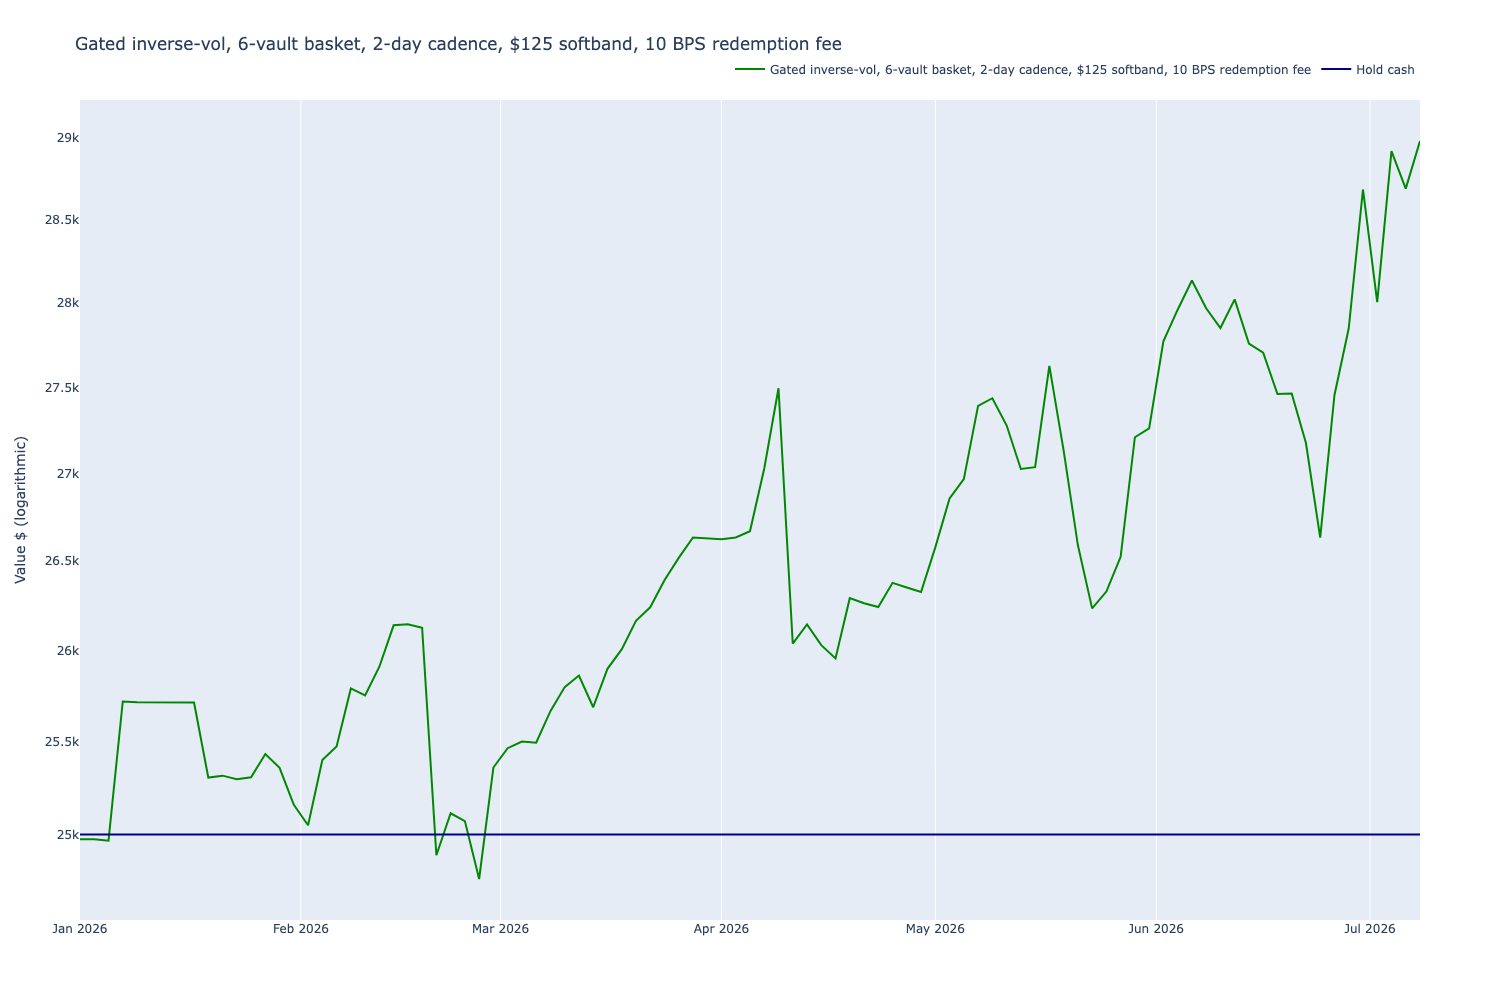

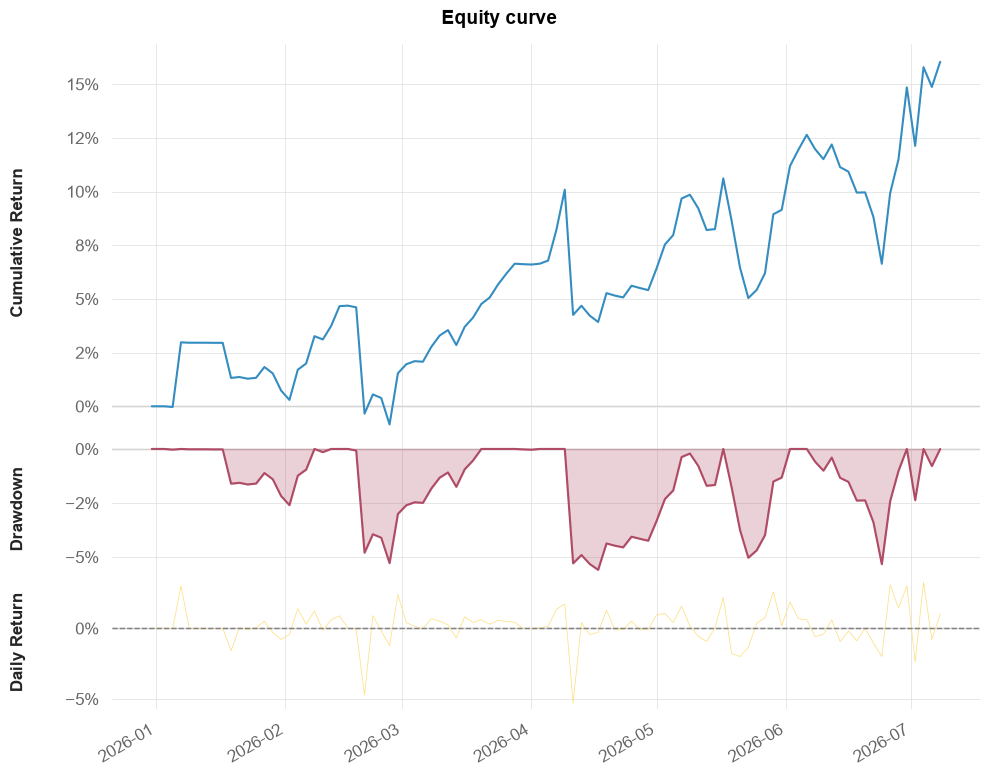

In [11]:
fig = chart_renderer.render(equity_curve_with_benchmark)
fig.show()

fig = chart_renderer.render(equity_curve_with_drawdown)
display(fig)


# Asset weights

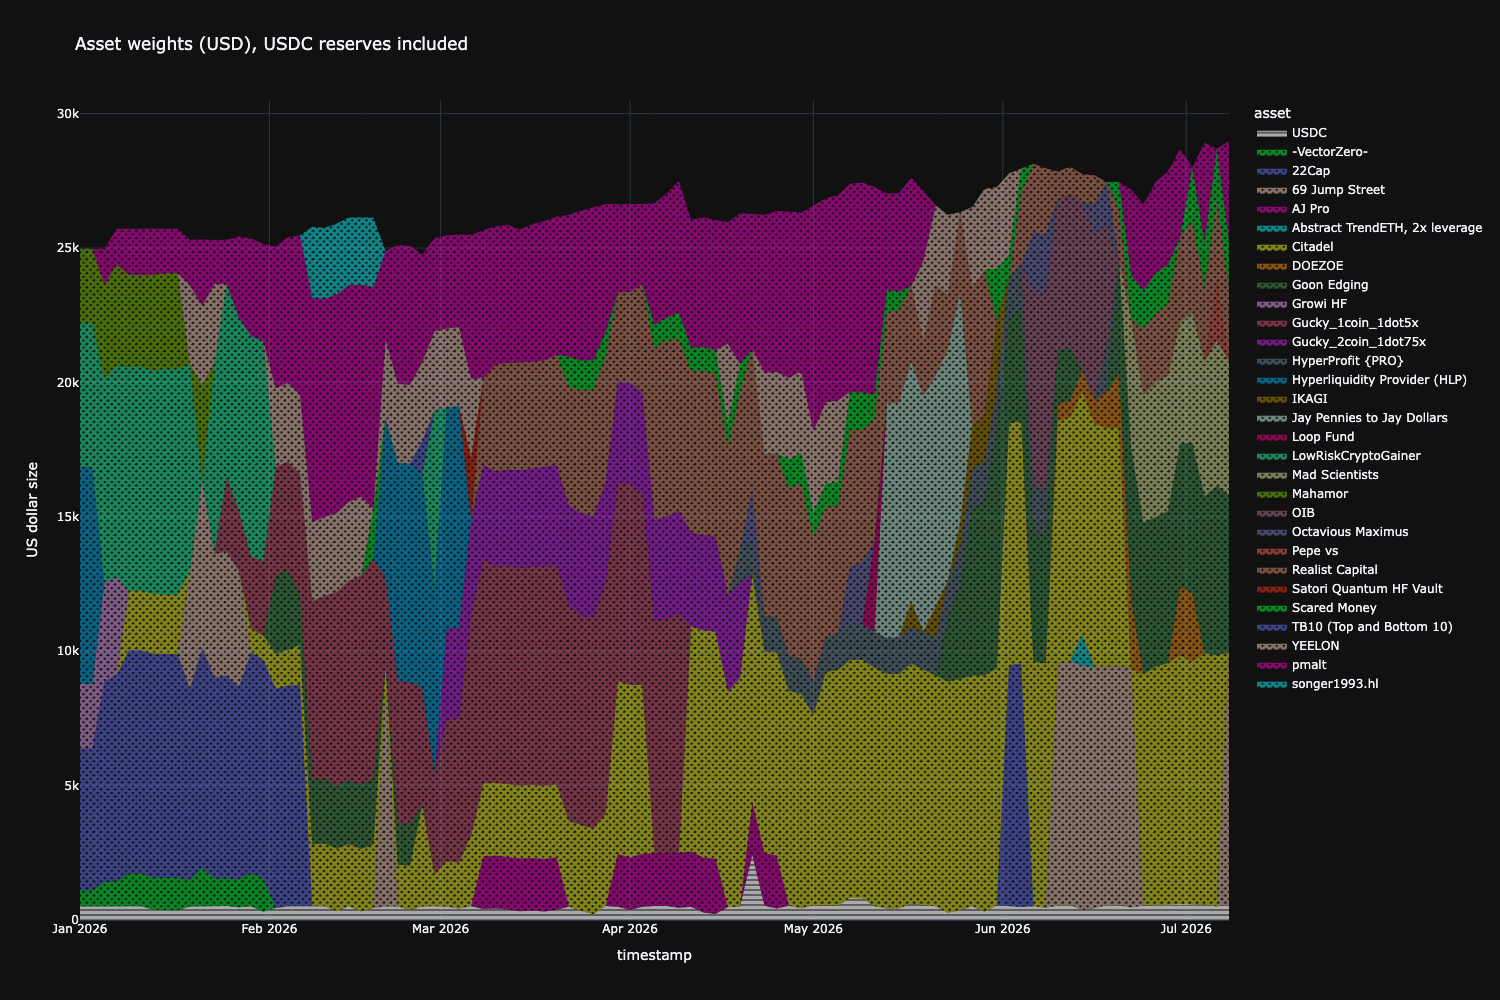

,At,Pair,Value,Address
Name,,,,
Max position (excluding USDC),2026-07-08,69 Jump Street,"$9,367.70",
Min position (excluding USDC),2026-01-01,-VectorZero-,$606.04,
Mean position (excluding USDC),,,"$4,324.28",
Max position (excluding USDC),2026-04-21,Citadel,35.66%,
Min position (excluding USDC),2026-06-10,DOEZOE,2.27%,
Mean position (excluding USDC),,,16.67%,
Max position (including USDC),2026-05-23,Citadel,32.78%,
Min position (including USDC),2026-03-26,USDC,0.82%,
Mean position (including USDC),,,14.29%,


In [12]:
from tradeexecutor.utils.notebook import display_dataframe_with_html

fig = chart_renderer.render(equity_curve_by_asset)
display(fig)

display_dataframe_with_html(chart_renderer.render(weight_allocation_statistics))


# Monthly returns

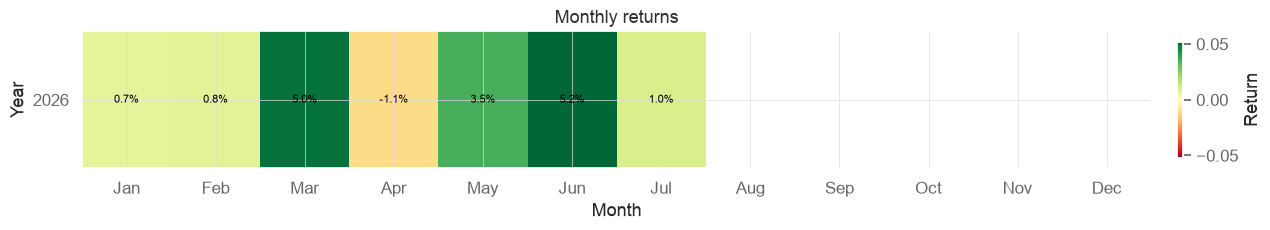

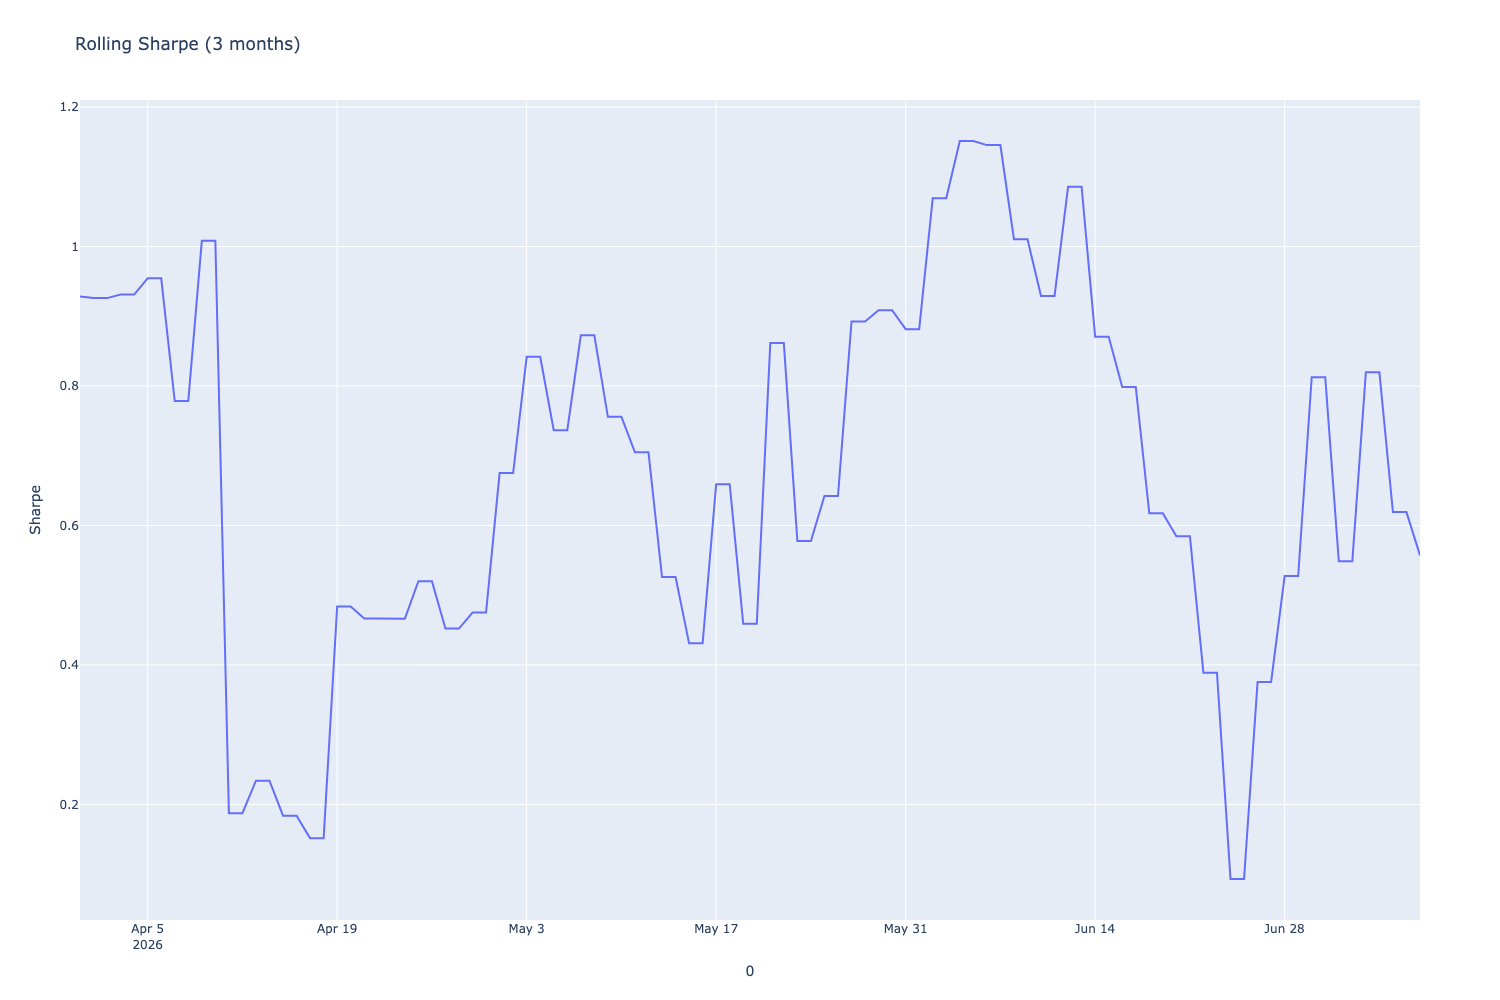

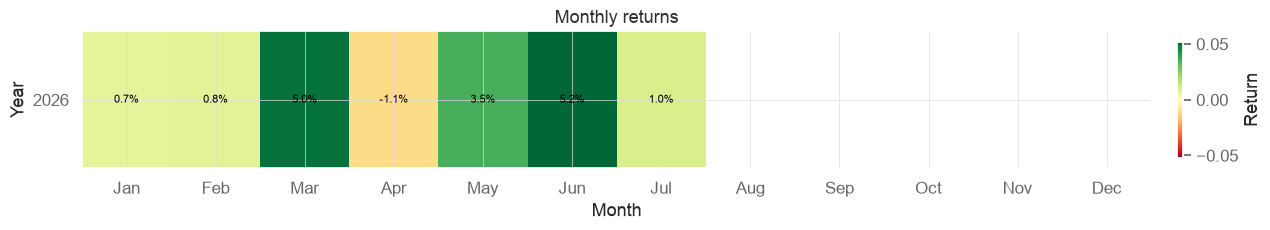

In [13]:
from tradeexecutor.visual.equity_curve import visualise_returns_over_time, calculate_rolling_sharpe
import plotly.express as px

display(visualise_returns_over_time(returns))

rolling_sharpe = calculate_rolling_sharpe(returns, freq="D", periods=90)
fig = px.line(rolling_sharpe, title="Rolling Sharpe (3 months)")
fig.update_layout(showlegend=False); fig.update_yaxes(title="Sharpe")
fig.show()


# Benchmark comparison and positions

In [14]:
from tradeexecutor.analysis.multi_asset_benchmark import compare_strategy_backtest_to_multiple_assets

display(compare_strategy_backtest_to_multiple_assets(state, strategy_universe, display=False, asset_count=2))

profit_by_position = sorted(
    ((p.get_realised_profit_usd() or 0.0, p) for p in positions),
    key=lambda x: x[0], reverse=True,
)
def pos_rows(items):
    return pd.DataFrame([{ 'Profit USD': pnl, 'Pair': p.pair.base.token_symbol,
        'Opened': p.opened_at, 'Closed': p.closed_at, 'Trades': len(p.trades) } for pnl, p in items])
print("Top 10 positions by profit:")
display(pos_rows(profit_by_position[:10]))
print("Biggest 8 losers:")
display(pos_rows(sorted(profit_by_position, key=lambda x: x[0])[:8]))

display(chart_renderer.render(positions_at_end))


,Strategy,BTC,ETH
Start Period,2026-01-01,2026-01-01,2026-01-01
End Period,2026-07-08,2026-07-08,2026-07-08
Risk-Free Rate,0,0,0
Time in Market,0.49,0.98,0.98
Cumulative Return,0.16,-0.32,-0.45
CAGR﹪,0.33,-0.52,-0.68
Sharpe,1.7,-1.28,-1.43
Prob. Sharpe Ratio,0.88,0.18,0.15
Smart Sharpe,1.69,-1.27,-1.42
Sortino,2.44,-1.72,-1.93


Top 10 positions by profit:


,Profit USD,Pair,Opened,Closed,Trades
0,1218.297746,Goon Edgin,2026-05-23,2026-06-14,11
1,1214.860050,Realist Ca,2026-03-08,2026-05-31,35
2,898.178117,pmalt,2026-01-05,2026-05-21,48
3,421.170249,Goon Edgin,2026-02-02,2026-02-20,8
4,386.043557,Realist Ca,2026-06-24,NaT,8
5,341.088975,Scared Mon,2026-04-27,2026-05-17,8
6,319.324541,HyperProfi,2026-04-19,2026-06-10,3
7,223.798432,Growi HF,2026-01-01,2026-01-09,4
8,219.704704,Realist Ca,2026-06-04,2026-06-18,7
9,165.883116,Goon Edgin,2026-06-20,NaT,10


Biggest 8 losers:


,Profit USD,Pair,Opened,Closed,Trades
0,-1288.358640,songer1993,2026-02-08,2026-02-20,4
1,-360.624260,Pepe vs,2026-07-06,2026-07-08,2
2,-346.318018,Citadel,2026-01-09,2026-01-19,2
3,-277.765709,IKAGI,2026-05-21,2026-05-23,2
4,-241.761747,Octavious,2026-06-06,2026-06-10,3
5,-190.493284,Goon Edgin,2026-02-22,2026-02-26,3
6,-171.054195,Scared Mon,2026-05-31,2026-06-06,3
7,-161.755737,-VectorZer,2026-01-01,2026-02-02,9


,token,value,vault,protocol,link
position_id,,,,,
58,Goon Edgin,5877.138662,Goon Edging,hyperliquid,0x2431edfcb662e6ff6deab113cc91878a0b53fb0f
61,Mad Scient,4982.010701,Mad Scientists,hyperliquid,0x565b1c32936bdaa526947178acc95c5b08cfacc4
64,Realist Ca,2732.348477,Realist Capital,hyperliquid,0x77fee2df7bad4f1db93052fa82bf78eaab771a16
66,Scared Mon,1732.864840,Scared Money,hyperliquid,0x5290ab34acb59cfe1371baa5782eba14433d308f
69,69 Jump St,9367.700404,69 Jump Street,hyperliquid,0xa844d7ac9fa3424c4fd38a25baa23e460ec3e802
70,pmalt,3710.232200,pmalt,hyperliquid,0x4dec0a851849056e259128464ef28ce78afa27f6


# Cash deployment diagnostics

Why does the strategy hold cash? Per cycle, the allocator redistributes equity a capped
position cannot take to the *remaining selected* signals, but it hard-stops at
`max_assets_in_portfolio` positions — so once all selected vaults hit their caps
(`per_position_cap_of_pool_pct` x vault TVL, or `max_concentration_pct` x investable equity),
the remainder is stranded as cash. This section quantifies which cap binds and how much
cash it strands, parsed from the per-cycle diagnostics messages.


,value
cycles,95.00
mean cash %,2.89
median cash %,1.89
max cash %,100.00
final-cycle cash %,1.72
mean deployment shortfall % of investable,0.08
cycles with shortfall > 10% of investable,0.00
mean signals pool-capped per cycle,1.23
mean signals concentration-capped per cycle,1.45
cycles where ALL selected signals were pool-capped,0.00


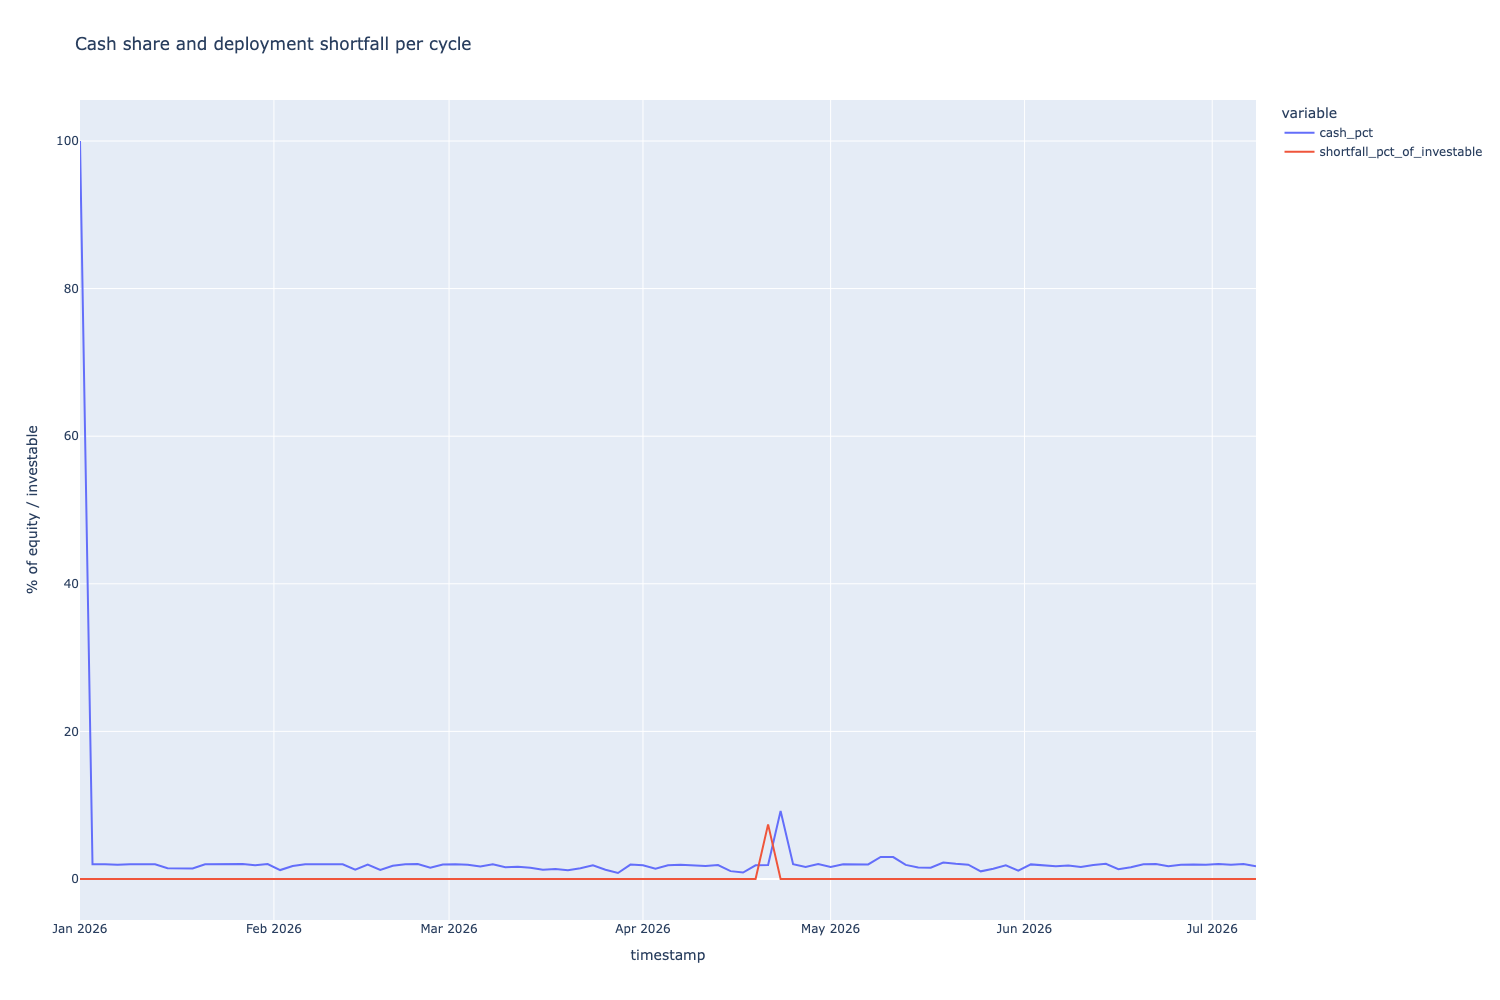

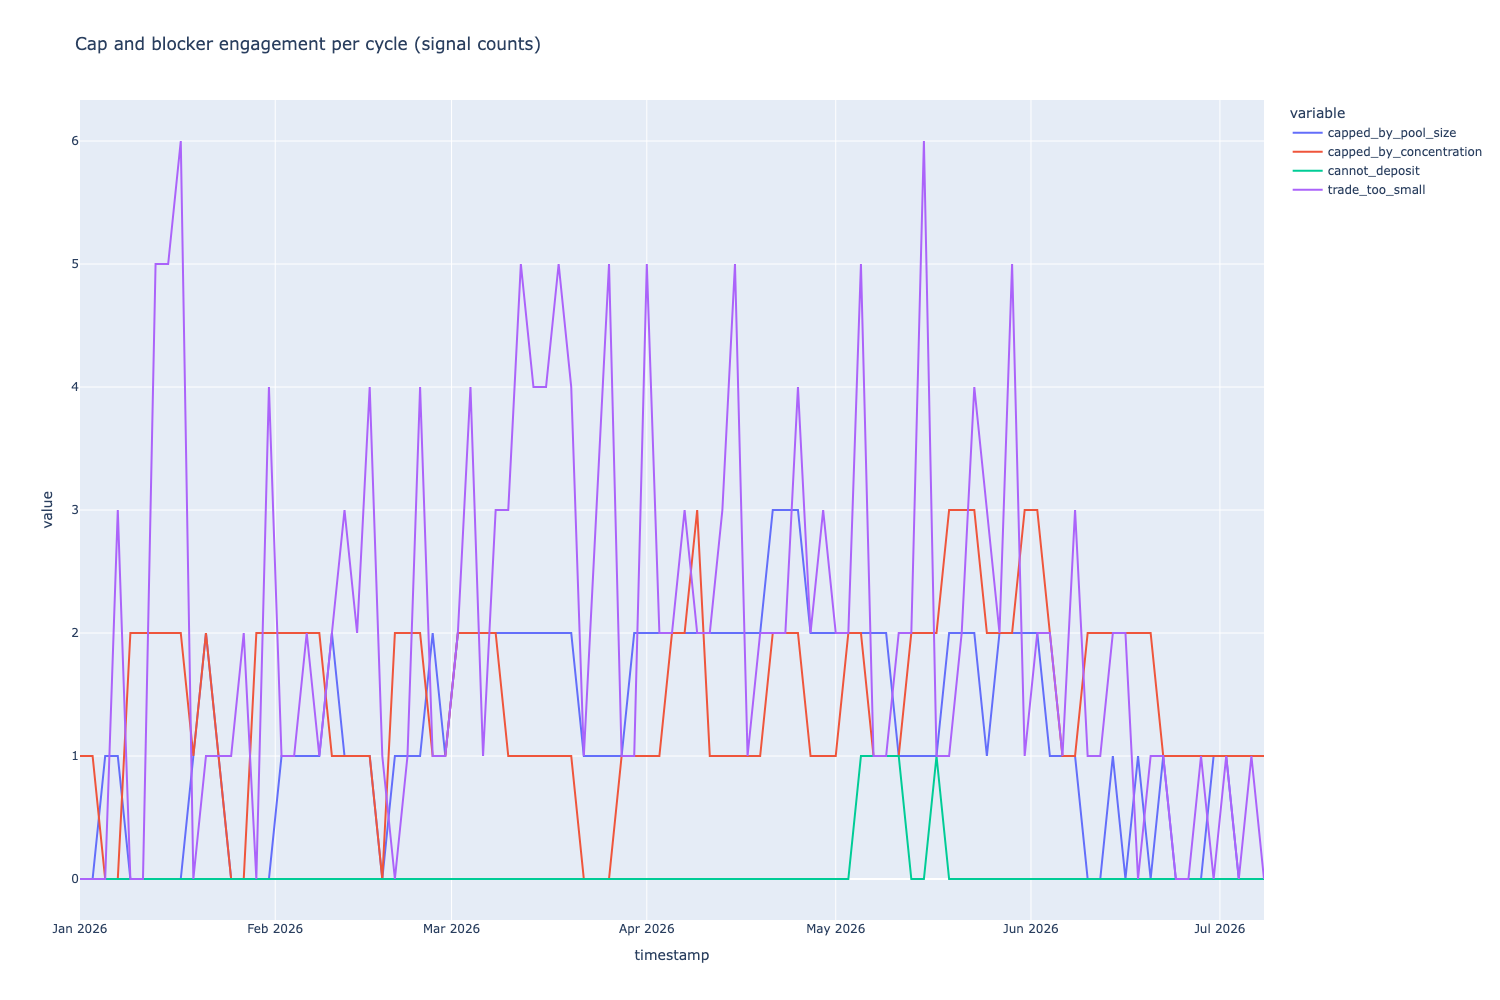

Last 30 cycles:


,cash_pct,cannot_deposit,deposit_window_skips,capped_by_pool_size,top_signal_pair
timestamp,,,,,
2026-05-11,3.0,1,2,1,Citadel-USDC
2026-05-13,1.9,0,2,1,Jay
2026-05-15,1.6,0,2,1,Jay
2026-05-17,1.5,1,2,1,Jay
2026-05-19,2.2,0,2,2,YEELON-USDC
2026-05-21,2.1,0,2,2,YEELON-USDC
2026-05-23,1.9,0,2,2,YEELON-USDC
2026-05-25,1.0,0,2,1,Jay
2026-05-27,1.4,0,2,2,YEELON-USDC


In [15]:
import re

import plotly.express as px


def extract_allocation_df(state) -> pd.DataFrame:
    """Parse per-cycle equity/cash/allocation and cap-flag counts from diagnostics messages."""
    rows = []
    for unix_ts, messages in sorted(state.visualisation.messages.items(), key=lambda item: item[0]):
        if not messages:
            continue
        message = '\n'.join(messages)

        def _usd(label):
            match = re.search(rf'{re.escape(label)}: ([0-9,.\-]+) USD', message)
            return float(match.group(1).replace(',', '')) if match else float('nan')

        def _count(label):
            match = re.search(rf'{re.escape(label)}: ([0-9]+)', message)
            return int(match.group(1)) if match else 0

        rows.append({
            'timestamp': datetime.datetime.fromtimestamp(unix_ts, datetime.timezone.utc).replace(tzinfo=None),
            'total_equity': _usd('Total equity'),
            'cash': _usd('Cash'),
            'investable': _usd('Investable equity'),
            'accepted': _usd('Accepted investable equity'),
            'discarded_liquidity': _usd('Discarded allocation because of lack of lit liquidity'),
            'candidates': _count('Candidate signals created'),
            'selected': _count('Selected survivor signals'),
            'capped_by_pool_size': _count('Signals with flag capped_by_pool_size'),
            'capped_by_concentration': _count('Signals with flag capped_by_concentration'),
            'cannot_deposit': _count('Signals with flag cannot_deposit'),
            'deposit_window_skips': _count('Candidates skipped for closed deposit window'),
            'trade_too_small': _count('Signals with flag individual_trade_size_too_small'),
            'top_signal_pair': (re.search(r'Top signal pair: (\S+)', message).group(1)
                                if re.search(r'Top signal pair: (\S+)', message) else None),
        })
    return pd.DataFrame(rows).set_index('timestamp')


alloc_df = extract_allocation_df(state)
alloc_df['cash_pct'] = alloc_df['cash'] / alloc_df['total_equity'] * 100
alloc_df['deployment_shortfall'] = alloc_df['investable'] - alloc_df['accepted']
alloc_df['shortfall_pct_of_investable'] = alloc_df['deployment_shortfall'] / alloc_df['investable'] * 100

deployment_summary = pd.Series({
    'cycles': len(alloc_df),
    'mean cash %': alloc_df['cash_pct'].mean(),
    'median cash %': alloc_df['cash_pct'].median(),
    'max cash %': alloc_df['cash_pct'].max(),
    'final-cycle cash %': alloc_df['cash_pct'].iloc[-1],
    'mean deployment shortfall % of investable': alloc_df['shortfall_pct_of_investable'].mean(),
    'cycles with shortfall > 10% of investable': int((alloc_df['shortfall_pct_of_investable'] > 10).sum()),
    'mean signals pool-capped per cycle': alloc_df['capped_by_pool_size'].mean(),
    'mean signals concentration-capped per cycle': alloc_df['capped_by_concentration'].mean(),
    'cycles where ALL selected signals were pool-capped': int(
        ((alloc_df['capped_by_pool_size'] >= alloc_df['selected']) & (alloc_df['selected'] > 0)).sum()
    ),
    'cycles with < 5 gated candidates': int((alloc_df['candidates'] < int(Parameters.max_assets_in_portfolio)).sum()),
    'cycles with a cannot_deposit signal (closed deposit window)': int((alloc_df['cannot_deposit'] > 0).sum()),
    'cycles skipping closed-window candidates at selection': int((alloc_df['deposit_window_skips'] > 0).sum()),
    'total closed-window candidates skipped at selection': int(alloc_df['deposit_window_skips'].sum()),
    'mean cash % when cannot_deposit engaged': alloc_df.loc[alloc_df['cannot_deposit'] > 0, 'cash_pct'].mean(),
    'mean cash % when no cannot_deposit': alloc_df.loc[alloc_df['cannot_deposit'] == 0, 'cash_pct'].mean(),
}, name='value')
display(deployment_summary.to_frame().round(2))

fig = px.line(alloc_df[['cash_pct', 'shortfall_pct_of_investable']], title='Cash share and deployment shortfall per cycle')
fig.update_yaxes(title='% of equity / investable')
fig.show()

fig = px.line(alloc_df[['capped_by_pool_size', 'capped_by_concentration', 'cannot_deposit', 'trade_too_small']], title='Cap and blocker engagement per cycle (signal counts)')
fig.show()

print('Last 30 cycles:')
display(alloc_df[['cash_pct', 'cannot_deposit', 'deposit_window_skips', 'capped_by_pool_size', 'top_signal_pair']].tail(30).round(1))


## End-of-backtest drill-down

The held vaults at the end, their TVL, and the pool cap each one imposes. If the sum of
pool caps is below investable equity, the cash pile is structural: the five selected
vaults simply cannot absorb the bankroll at a 15% TVL share.


In [16]:
final_rows = []
for position in state.portfolio.open_positions.values():
    pair = position.pair
    try:
        tvl_series = indicator_data.get_indicator_series('tvl', pair=pair)
        last_tvl = float(tvl_series.dropna().iloc[-1])
    except Exception:
        last_tvl = float('nan')
    final_rows.append({
        'Vault': pair.base.token_symbol,
        'Position value USD': float(position.get_value()),
        'Vault TVL USD': last_tvl,
        'Pool cap (15% of TVL) USD': last_tvl * float(Parameters.per_position_cap_of_pool_pct),
    })
final_positions_df = pd.DataFrame(final_rows).sort_values('Position value USD', ascending=False)
display(final_positions_df.round(0))

final_cycle = alloc_df.iloc[-1]
print(f"Final cycle equity: {final_cycle['total_equity']:,.0f} USD, cash: {final_cycle['cash']:,.0f} USD ({final_cycle['cash_pct']:.1f}%)")
print(f"Investable (98% target): {final_cycle['investable']:,.0f} USD, accepted by caps: {final_cycle['accepted']:,.0f} USD")
print(f"Sum of pool caps across held vaults: {final_positions_df['Pool cap (15% of TVL) USD'].sum():,.0f} USD")

print()
print('Last cycle raw diagnostics:')
last_ts = max(state.visualisation.messages)
print('\n'.join(state.visualisation.messages[last_ts]))


,Vault,Position value USD,Vault TVL USD,Pool cap (15% of TVL) USD
4,69 Jump St,9368.0,258067.0,38710.0
0,Goon Edgin,5877.0,108169.0,16225.0
1,Mad Scient,4982.0,59388.0,8908.0
5,pmalt,3710.0,513987.0,77098.0
2,Realist Ca,2732.0,485292.0,72794.0
3,Scared Mon,1733.0,50278.0,7542.0


Final cycle equity: 28,995 USD, cash: 500 USD (1.7%)
Investable (98% target): 28,415 USD, accepted by caps: 28,415 USD
Sum of pool caps across held vaults: 221,277 USD

Last cycle raw diagnostics:
Cycle: #95
Rebalanced: 👍
Open/about to open positions: 8
Max position value change: 9,377.08 USD
Rebalance threshold: 12.50 USD
Trades decided: 8
Pairs meeting inclusion criteria: 195
Pairs meeting TVL inclusion criteria: 198
Candidate signals created: 183
Selected survivor signals: 8
Candidates skipped for closed deposit window: 1
CAGR lookback days: 360
Sharpe lookback days: 180
CAGR weight (blend): 0.5
Total equity: 28,995.29 USD
Cash: 499.68 USD
Redeemable capital: 28,495.61 USD
Pending redemptions: 0.00 USD
Investable equity: 28,415.39 USD
Accepted investable equity: 28,415.39 USD
Allocated to signals: 28,415.39 USD
Discarded allocation because of lack of lit liquidity: 0.00 USD
Rebalance volume: 0.00 USD
Top signal pair: 69 Jump St-USDC
Top signal value: 250.86121398252962
Top signal we

# Redemption fee verification and cost accounting

Verify the fee actually reached the executed sell prices, and total up what it cost.

Two sell paths exist and both must be checked:

- **Full closes** go through `PositionManager.close_position()`, which prices straight off
  `BacktestPricing.get_sell_price()`, so the fee lands as `share price x (1 - fee)`.
- **Partial reductions** of a Hypercore position go through `PositionManager.adjust_position()`,
  which overrides the pricing-model price with the position's *marked* price
  (trade-executor `7e673dc6`, so live partial redemptions size off the live implied share price).
  That marked price is itself produced by `BacktestValuationModel` from `get_sell_price()` at the
  same cycle timestamp, so the fee is still charged — but the trade's `planned_mid_price` is
  overwritten with the same value and can no longer be used to measure it.

The verification below is therefore independent of both paths: it compares each executed sell
price against the vault's own daily close (share price) at the time the trade was planned.


,Trades,Configured fee,Median implied fee,Mean implied fee,Within 1 BPS of configured
Sell type,,,,,
Full close,64,0.100%,0.100%,-1.503%,53.1%
Partial reduction,104,0.100%,0.100%,0.116%,47.1%
All sells,168,0.100%,0.100%,-0.500%,49.4%


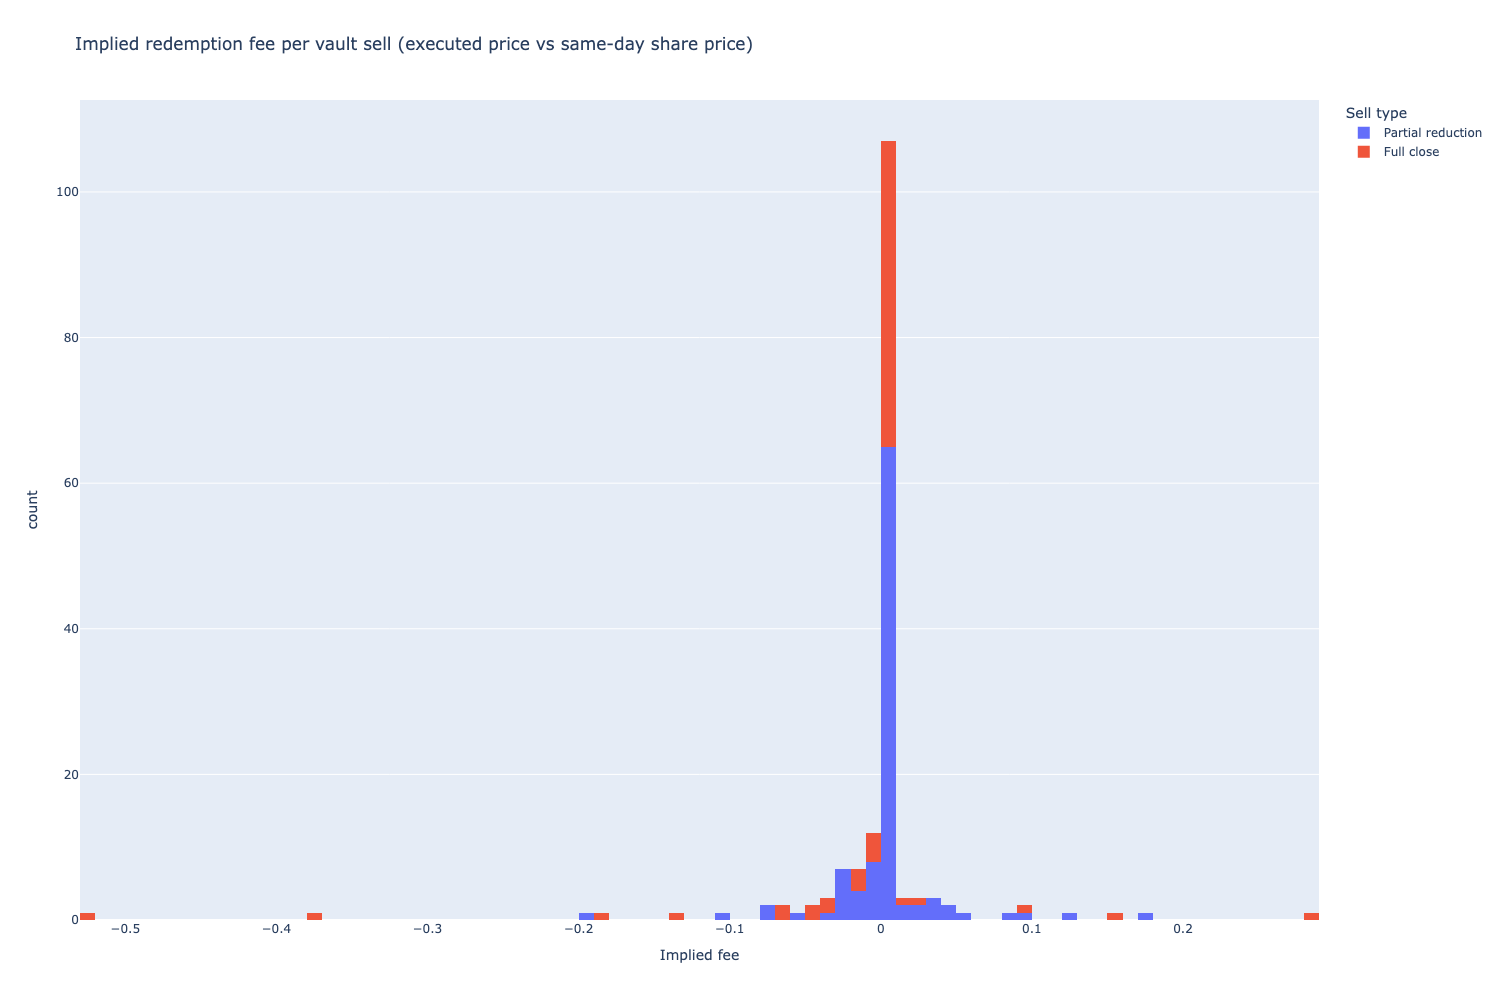

,Vault sell trades,Redemption volume USD,Redemption fee paid USD,Fee as % of initial capital,Fee as % of final equity,Redemption turnover x initial capital
0,168,"$307,187",$307,1.23%,1.06%,12.3x


,Sells,Proceeds USD,Fee paid USD
Vault,,,
Citadel,15,"$33,790",$33.82
pmalt,23,"$28,132",$28.16
69 Jump St,7,"$23,553",$23.58
LowRiskCry,4,"$23,058",$23.08
Realist Ca,22,"$21,946",$21.97
YEELON,7,"$20,865",$20.89
22Cap,5,"$19,696",$19.72
Hyperliqui,4,"$17,594",$17.61
Goon Edgin,13,"$17,297",$17.31


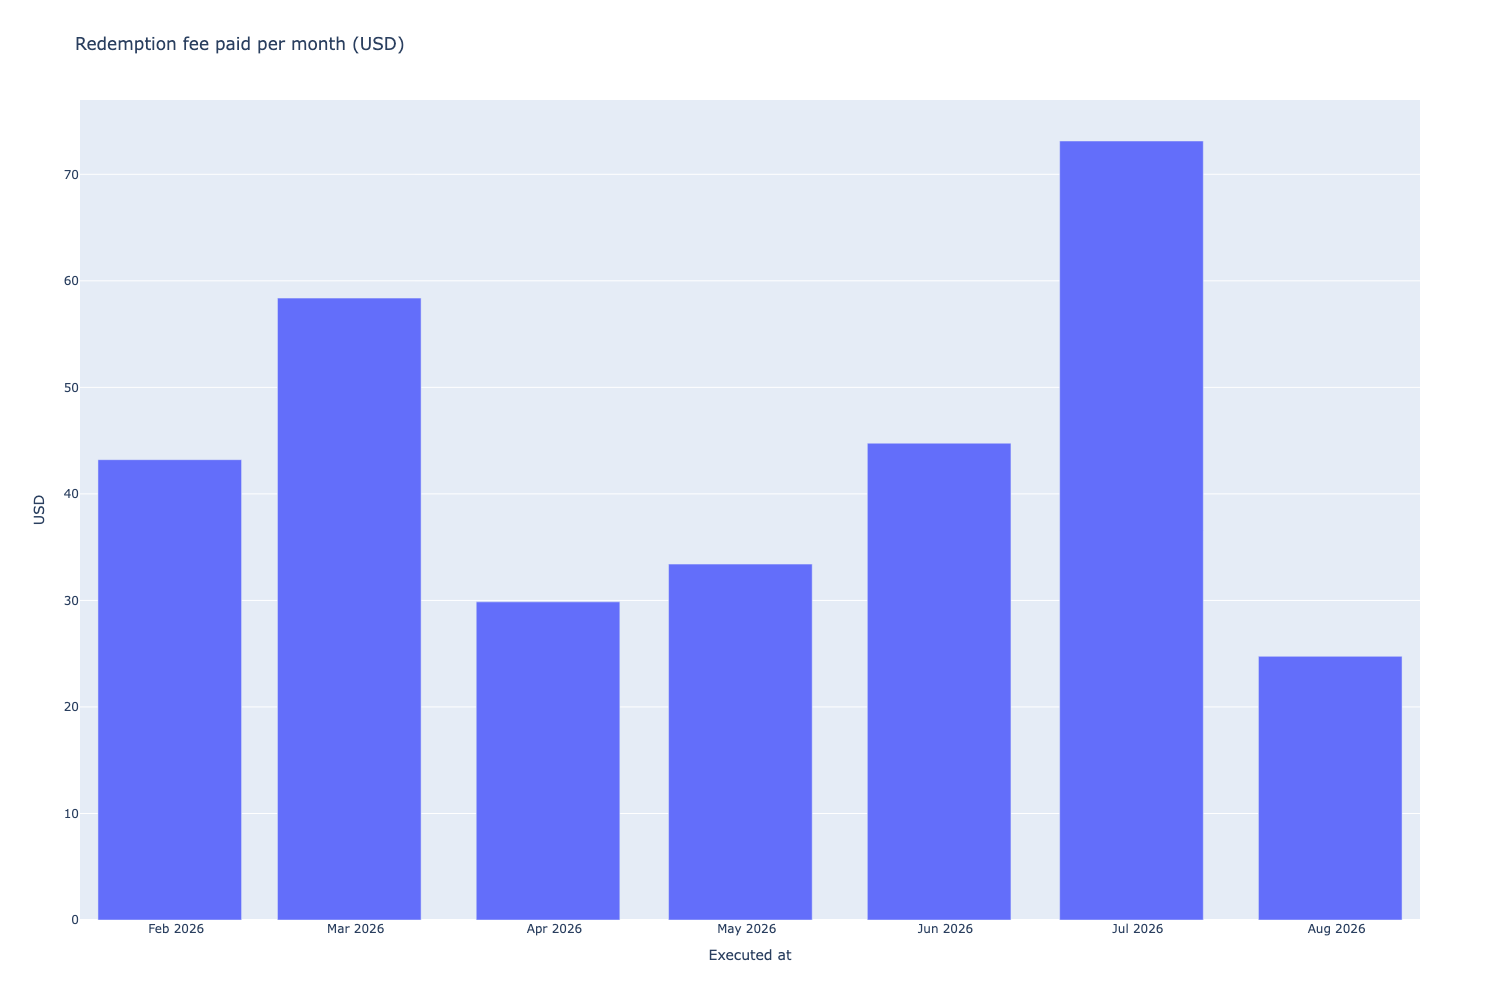

In [17]:
vault_close_cache = {}


def get_vault_share_price(pair, ts) -> float:
    """Vault share price (daily close) as of ``ts``, straight from the candle data."""
    closes = vault_close_cache.get(pair.internal_id)
    if closes is None:
        candles = strategy_universe.data_universe.candles.get_candles_by_pair(pair.internal_id)
        closes = candles.set_index('timestamp')['close'].sort_index()
        vault_close_cache[pair.internal_id] = closes
    window = closes.loc[closes.index <= pd.Timestamp(ts)]
    return float(window.iloc[-1]) if len(window) else float('nan')


def build_vault_sell_df(state_, fee_: float) -> pd.DataFrame:
    """Every successful vault sell, with the fee implied by its executed price.

    :param fee_:
        Redemption fee configured for the run that produced ``state_``.
    """
    rows = []
    for trade in state_.portfolio.get_all_trades():
        if not trade.pair.is_vault():
            continue
        if not trade.is_sell() or not trade.is_success():
            continue
        share_price = get_vault_share_price(trade.pair, trade.opened_at)
        proceeds = abs(float(trade.executed_reserve or 0.0))
        rows.append({
            'Vault': trade.pair.base.token_symbol,
            'Planned at': trade.opened_at,
            'Executed at': trade.executed_at,
            'Sell type': 'Full close' if trade.closing else 'Partial reduction',
            'Share price': share_price,
            'Planned price': float(trade.planned_price),
            'Implied fee': float(1.0 - trade.planned_price / share_price) if share_price == share_price else float('nan'),
            'Proceeds USD': proceeds,
            'Fee paid USD': proceeds * fee_ / (1.0 - fee_) if fee_ else 0.0,
        })
    return pd.DataFrame(rows)


def summarise_implied_fees(df: pd.DataFrame, fee_: float) -> pd.DataFrame:
    """Implied-fee statistics, split by sell type."""
    rows = []
    for sell_type, group in list(df.groupby('Sell type')) + [('All sells', df)]:
        implied = group['Implied fee'].dropna()
        rows.append({
            'Sell type': sell_type,
            'Trades': len(group),
            'Configured fee': fee_,
            'Median implied fee': float(implied.median()),
            'Mean implied fee': float(implied.mean()),
            'Within 1 BPS of configured': float((implied.sub(fee_).abs() <= 0.0001).mean()),
        })
    return pd.DataFrame(rows).set_index('Sell type')


fee = Parameters.vault_redemption_fee
vault_sell_df = build_vault_sell_df(state, fee)

display(
    summarise_implied_fees(vault_sell_df, fee).style.format({
        'Configured fee': '{:.3%}',
        'Median implied fee': '{:.3%}',
        'Mean implied fee': '{:.3%}',
        'Within 1 BPS of configured': '{:.1%}',
    }).set_caption('Implied redemption fee by sell type')
)

fig = px.histogram(
    vault_sell_df,
    x='Implied fee',
    color='Sell type',
    nbins=120,
    title='Implied redemption fee per vault sell (executed price vs same-day share price)',
)
fig.show()

total_fee_usd = float(vault_sell_df['Fee paid USD'].sum())
total_proceeds_usd = float(vault_sell_df['Proceeds USD'].sum())
final_equity = float(equity.iloc[-1])

fee_summary_df = pd.DataFrame([{
    'Vault sell trades': len(vault_sell_df),
    'Redemption volume USD': total_proceeds_usd,
    'Redemption fee paid USD': total_fee_usd,
    'Fee as % of initial capital': total_fee_usd / Parameters.initial_cash,
    'Fee as % of final equity': total_fee_usd / final_equity,
    'Redemption turnover x initial capital': total_proceeds_usd / Parameters.initial_cash,
}])
display(fee_summary_df.style.format({
    'Redemption volume USD': '${:,.0f}',
    'Redemption fee paid USD': '${:,.0f}',
    'Fee as % of initial capital': '{:.2%}',
    'Fee as % of final equity': '{:.2%}',
    'Redemption turnover x initial capital': '{:.1f}x',
}))

fee_by_vault_df = vault_sell_df.groupby('Vault').agg(
    **{
        'Sells': ('Proceeds USD', 'size'),
        'Proceeds USD': ('Proceeds USD', 'sum'),
        'Fee paid USD': ('Fee paid USD', 'sum'),
    }
).sort_values('Fee paid USD', ascending=False)
display(
    fee_by_vault_df.head(15).style.format({
        'Proceeds USD': '${:,.0f}',
        'Fee paid USD': '${:,.2f}',
    }).set_caption('Redemption fee paid by vault (top 15)')
)

monthly_fee = vault_sell_df.set_index('Executed at')['Fee paid USD'].resample('1ME').sum()
fig = px.bar(monthly_fee, title='Redemption fee paid per month (USD)')
fig.update_layout(showlegend=False)
fig.update_yaxes(title='USD')
fig.show()


# A/B against the same run without the redemption fee

The honest way to price the fee is to re-run the identical strategy on the identical universe
with the fee switched off, rather than to compare against NB53's committed numbers (vault data
is refreshed between runs, so those numbers drift for reasons unrelated to the fee).

The only difference between the two runs below is the vault sell-side fee.


In [18]:
# Same universe, same indicators, same decide_trades - only the redemption fee differs.
apply_vault_redemption_fee(strategy_universe, 0.0)

baseline_result = run_backtest_inline(
    name="Gated inverse-vol, 6-vault basket, 2-day cadence, $125 softband, no redemption fee",
    engine_version="0.5",
    decide_trades=decide_trades,
    indicator_combinations=indicator_data.indicator_combinations,
    cycle_duration=Parameters.cycle_duration,
    client=client,
    universe=strategy_universe,
    parameters=parameters,
    max_workers=1,
    start_at=Parameters.backtest_start,
    end_at=Parameters.backtest_end,
)

# Restore the configured fee so the rest of the notebook sees the fee-charging universe.
apply_vault_redemption_fee(strategy_universe, Parameters.vault_redemption_fee)

baseline_state = baseline_result.state
baseline_equity = calculate_equity_curve(baseline_state)
baseline_returns = calculate_returns(baseline_equity)
baseline_positions = [p for p in baseline_state.portfolio.get_all_positions() if not p.is_credit_supply()]
print(f"Baseline (no fee) final equity: ${baseline_equity.iloc[-1]:,.0f}")
print(f"10 BPS fee       final equity: ${equity.iloc[-1]:,.0f}")


Baseline (no fee) final equity: $29,349
10 BPS fee       final equity: $28,982


,Final equity,Cumulative return,CAGR,Sharpe,Sortino,Max drawdown,Positions,Trades
"Baseline, no redemption fee","$29,349",17.40%,36.53%,1.83,2.65,-5.55%,70,421
10 BPS redemption fee,"$28,982",15.93%,33.49%,1.70,2.44,-5.60%,70,420
Difference,$-367,-1.47%,-3.04%,-0.13,-0.21,-0.05%,0,-1


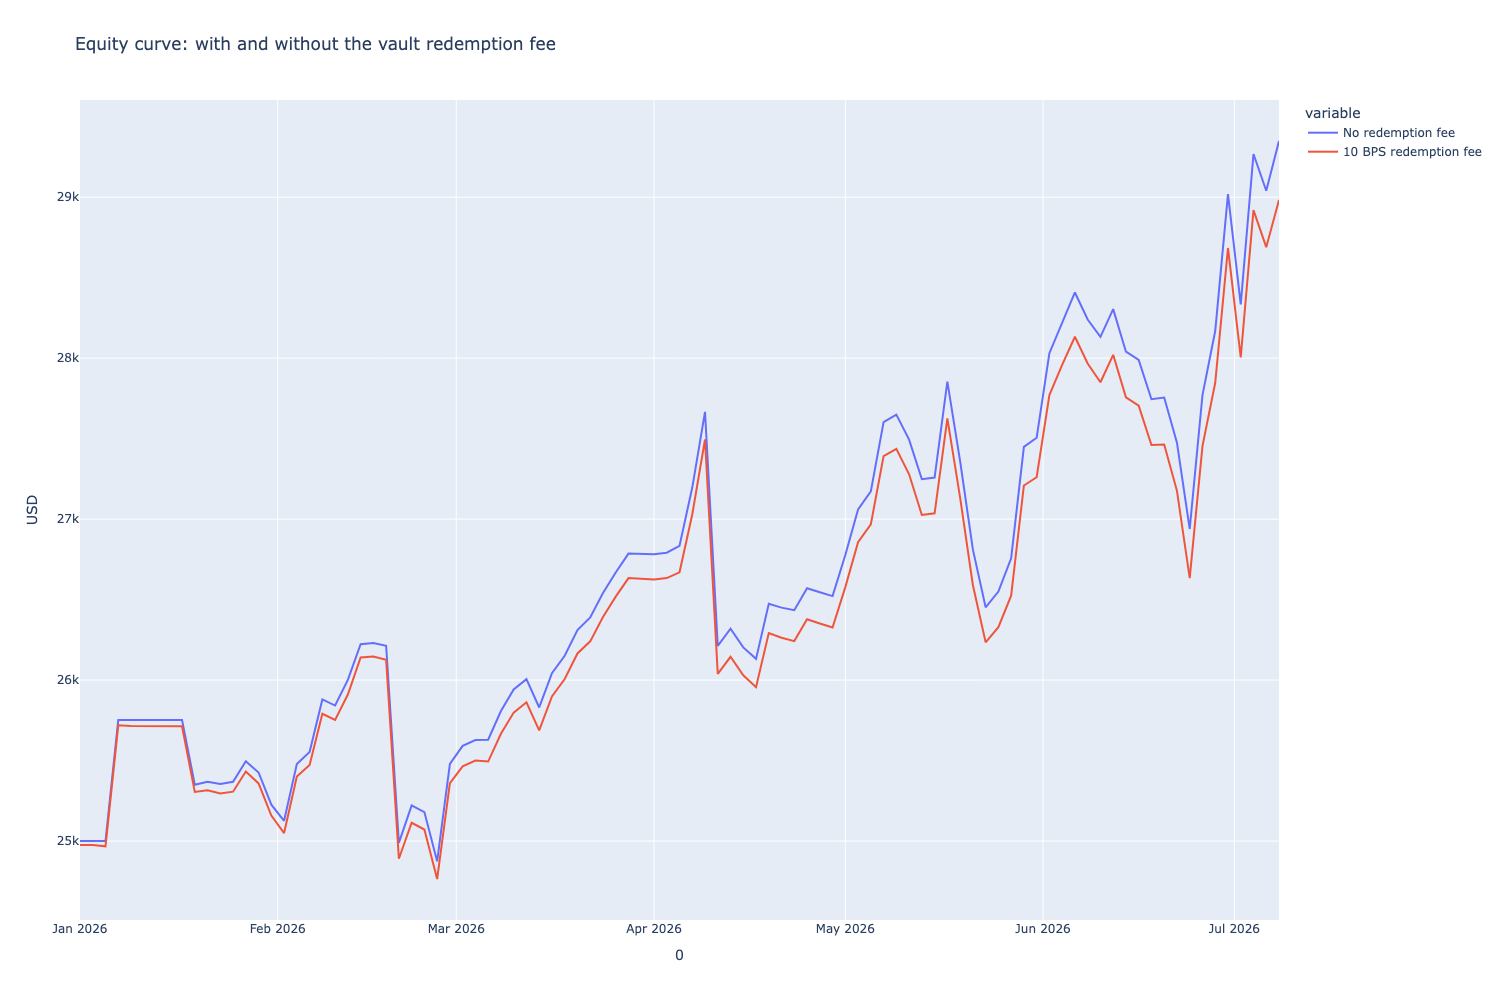

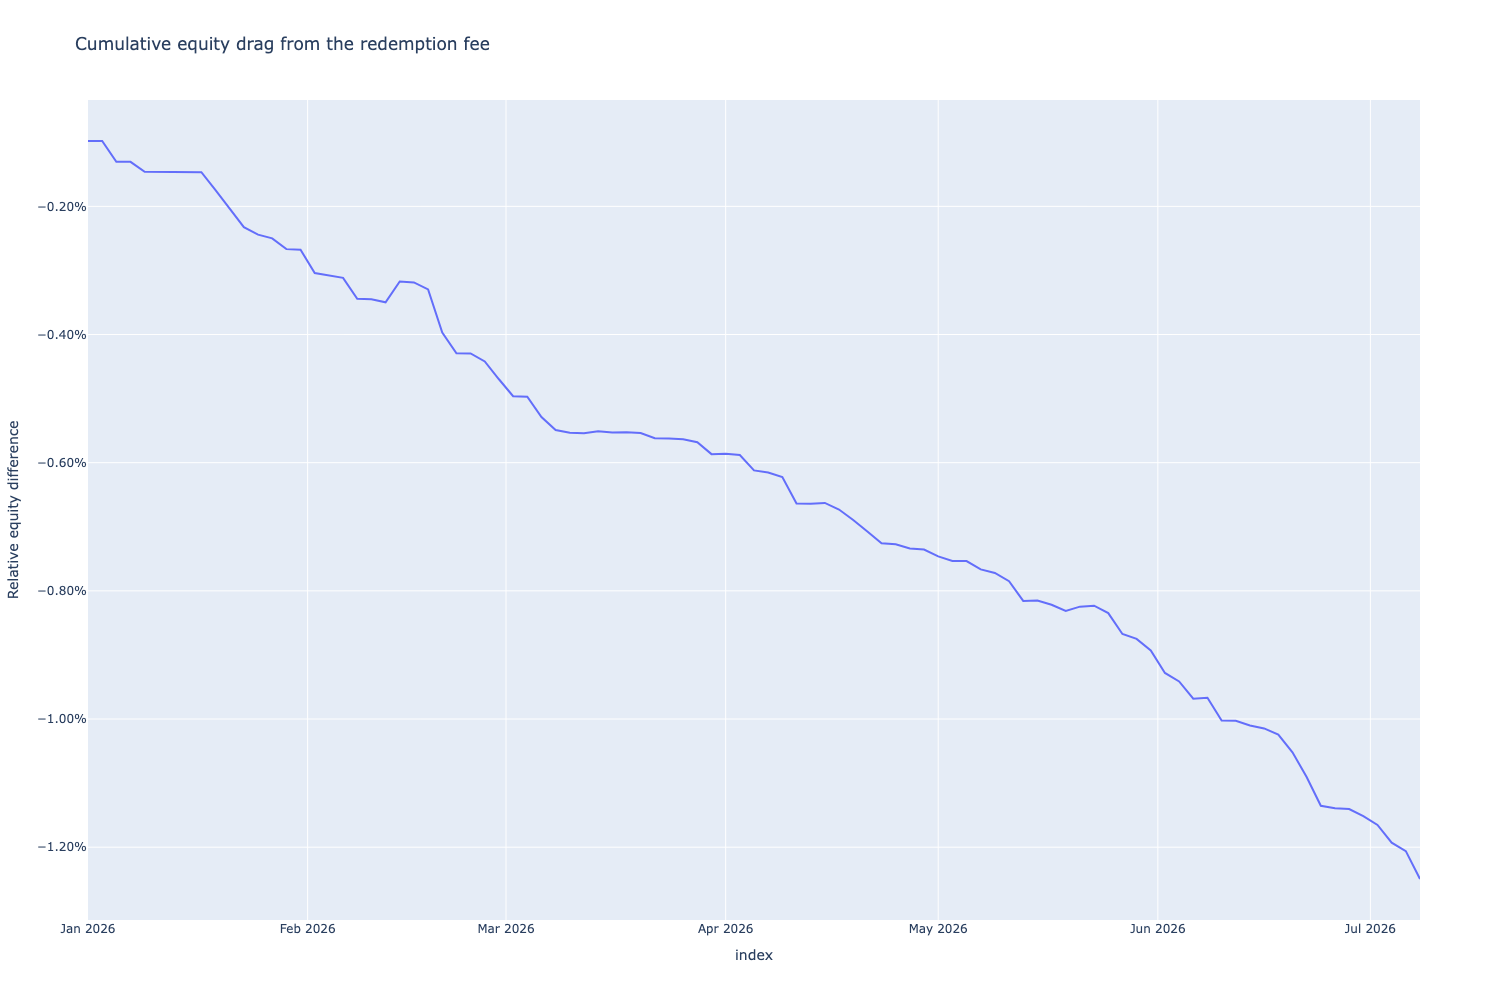

,Final equity difference USD,Final relative drag,Worst relative drag,Drag per year,Redemption fee paid USD (accounting)
0,$-367,-1.25%,-1.25%,-2.43%,$307


In [19]:
from tradeexecutor.statistics.key_metric import (
    calculate_cagr,
    calculate_max_drawdown,
    calculate_sharpe,
    calculate_sortino,
)


def summarise_run(label: str, equity_curve: pd.Series, state_) -> dict:
    """Headline metrics for one backtest run.

    The equity curve is sampled **once per strategy cycle**, so a 2-day cadence produces one
    observation every 48 hours. Annualising that series with ``periods=365`` would overstate its
    Sharpe and Sortino by ``sqrt(2)`` against a daily-cadence run and make the two incomparable.
    Resample onto a common daily grid first - a 2-day step becomes one non-zero day and one zero
    day, which annualises correctly and matches the basis used in the robustness cell.

    Max drawdown is still measured on whatever grid the strategy values itself: a 2-day cadence
    cannot observe a trough that opens and closes inside one of its cycles, so its drawdown is
    measured over fewer marks than a daily cadence. That is a property of the schedule, not of
    this function.
    """
    return_series = calculate_returns(equity_curve).resample("1D").sum(min_count=1).fillna(0.0).dropna()
    trades = list(state_.portfolio.get_all_trades())
    run_positions = [p for p in state_.portfolio.get_all_positions() if not p.is_credit_supply()]
    return {
        'Run': label,
        'Final equity': float(equity_curve.iloc[-1]),
        'Cumulative return': float(equity_curve.iloc[-1] / Parameters.initial_cash - 1.0),
        'CAGR': float(calculate_cagr(return_series)),
        'Sharpe': float(calculate_sharpe(return_series, periods=365)),
        'Sortino': float(calculate_sortino(return_series, periods=365)),
        'Max drawdown': float(calculate_max_drawdown(return_series)),
        'Positions': len(run_positions),
        'Trades': len(trades),
    }


comparison_df = pd.DataFrame([
    summarise_run('Baseline, no redemption fee', baseline_equity, baseline_state),
    summarise_run(f'{Parameters.vault_redemption_fee * 10_000:.0f} BPS redemption fee', equity, state),
]).set_index('Run')
delta = comparison_df.iloc[1] - comparison_df.iloc[0]
delta.name = 'Difference'
comparison_df = pd.concat([comparison_df, delta.to_frame().T])
display(comparison_df.style.format({
    'Final equity': '${:,.0f}',
    'Cumulative return': '{:.2%}',
    'CAGR': '{:.2%}',
    'Sharpe': '{:.2f}',
    'Sortino': '{:.2f}',
    'Max drawdown': '{:.2%}',
    'Positions': '{:.0f}',
    'Trades': '{:.0f}',
}))

equity_comparison_df = pd.DataFrame({
    'No redemption fee': baseline_equity,
    f'{Parameters.vault_redemption_fee * 10_000:.0f} BPS redemption fee': equity,
}).ffill()
fig = px.line(equity_comparison_df, title='Equity curve: with and without the vault redemption fee')
fig.update_yaxes(title='USD')
fig.show()

drag = (equity_comparison_df.iloc[:, 1] / equity_comparison_df.iloc[:, 0] - 1.0)
fig = px.line(drag, title='Cumulative equity drag from the redemption fee')
fig.update_layout(showlegend=False)
fig.update_yaxes(title='Relative equity difference', tickformat='.2%')
fig.show()

drag_df = pd.DataFrame([{
    'Final equity difference USD': float(equity.iloc[-1] - baseline_equity.iloc[-1]),
    'Final relative drag': float(drag.iloc[-1]),
    'Worst relative drag': float(drag.min()),
    'Drag per year': float(drag.iloc[-1]) / ((equity.index[-1] - equity.index[0]).days / 365.0),
    'Redemption fee paid USD (accounting)': total_fee_usd,
}])
display(drag_df.style.format({
    'Final equity difference USD': '${:,.0f}',
    'Final relative drag': '{:.2%}',
    'Worst relative drag': '{:.2%}',
    'Drag per year': '{:.2%}',
    'Redemption fee paid USD (accounting)': '${:,.0f}',
}))


In [20]:
# Control: the same implied-fee measurement on the no-fee baseline run.
#
# Hypercore partial reductions execute at the position's marked price, which is a cycle-start
# valuation and can differ from the same-day close for reasons that have nothing to do with the
# fee (stale marks, positions opened the same cycle, async settlement). The baseline run isolates
# that measurement noise: its implied fees must centre on zero, and the fee run must be the same
# distribution shifted by exactly the configured fee.
baseline_sell_df = build_vault_sell_df(baseline_state, 0.0)

control_df = pd.concat([
    summarise_implied_fees(baseline_sell_df, 0.0).assign(Run='Baseline, no fee'),
    summarise_implied_fees(vault_sell_df, Parameters.vault_redemption_fee).assign(Run='10 BPS fee'),
]).set_index('Run', append=True).reorder_levels(['Run', 'Sell type'])
display(control_df.style.format({
    'Configured fee': '{:.3%}',
    'Median implied fee': '{:.3%}',
    'Mean implied fee': '{:.3%}',
    'Within 1 BPS of configured': '{:.1%}',
}).set_caption('Implied fee measurement, fee run vs no-fee control'))

shift_df = pd.DataFrame([{
    'Median implied fee, baseline': float(baseline_sell_df['Implied fee'].median()),
    'Median implied fee, fee run': float(vault_sell_df['Implied fee'].median()),
    'Median shift': float(vault_sell_df['Implied fee'].median() - baseline_sell_df['Implied fee'].median()),
    'Mean shift': float(vault_sell_df['Implied fee'].mean() - baseline_sell_df['Implied fee'].mean()),
    'Configured fee': Parameters.vault_redemption_fee,
}])
display(shift_df.style.format('{:.3%}'))


,"Median implied fee, baseline","Median implied fee, fee run",Median shift,Mean shift,Configured fee
0,0.000%,0.100%,0.100%,0.097%,0.100%


# Cadence x softband factorial at 10 BPS

The A/B above prices the fee under one schedule. This section separates the two mitigation levers
from each other on this window: daily against 2-day rebalancing, crossed with the $5 floor against
the $250 softband, all at 10 BPS on the same universe, indicators and `decide_trades`.

The daily / $5 cell is the inherited NB59 configuration, so it doubles as a reproduction check.


Running Daily, $5 band (NB59 configuration) ...


Running Daily, $125 band ...


Running Daily, $250 band ...


Running 2-day, $5 band ...


Running 2-day, $125 band (this notebook) ...


Running 2-day, $250 band ...


,Final equity,Cumulative return,CAGR,Sharpe,Sortino,Max drawdown,Positions,Trades,Vault sells,Exits,Trims,Redemption volume,Turnover x capital,Fee paid
Run,,,,,,,,,,,,,,
"Daily, $5 band (NB59 configuration)","$27,090",8.36%,17.00%,0.95,1.29,-7.65%,83,858,418,77,341,"$403,991",16.2x,$404
"Daily, $125 band","$27,090",8.36%,17.00%,0.95,1.29,-7.65%,83,629,233,77,156,"$399,282",16.0x,$400
"Daily, $250 band","$27,158",8.63%,17.56%,0.97,1.32,-7.69%,83,568,194,77,117,"$396,447",15.9x,$397
"2-day, $5 band","$29,005",16.02%,33.70%,1.72,2.46,-5.60%,70,511,241,64,177,"$308,872",12.4x,$309
"2-day, $125 band (this notebook)","$28,982",15.93%,33.49%,1.70,2.44,-5.60%,70,420,168,64,104,"$307,187",12.3x,$307
"2-day, $250 band","$29,060",16.24%,34.19%,1.73,2.48,-5.65%,70,388,142,64,78,"$306,034",12.2x,$306


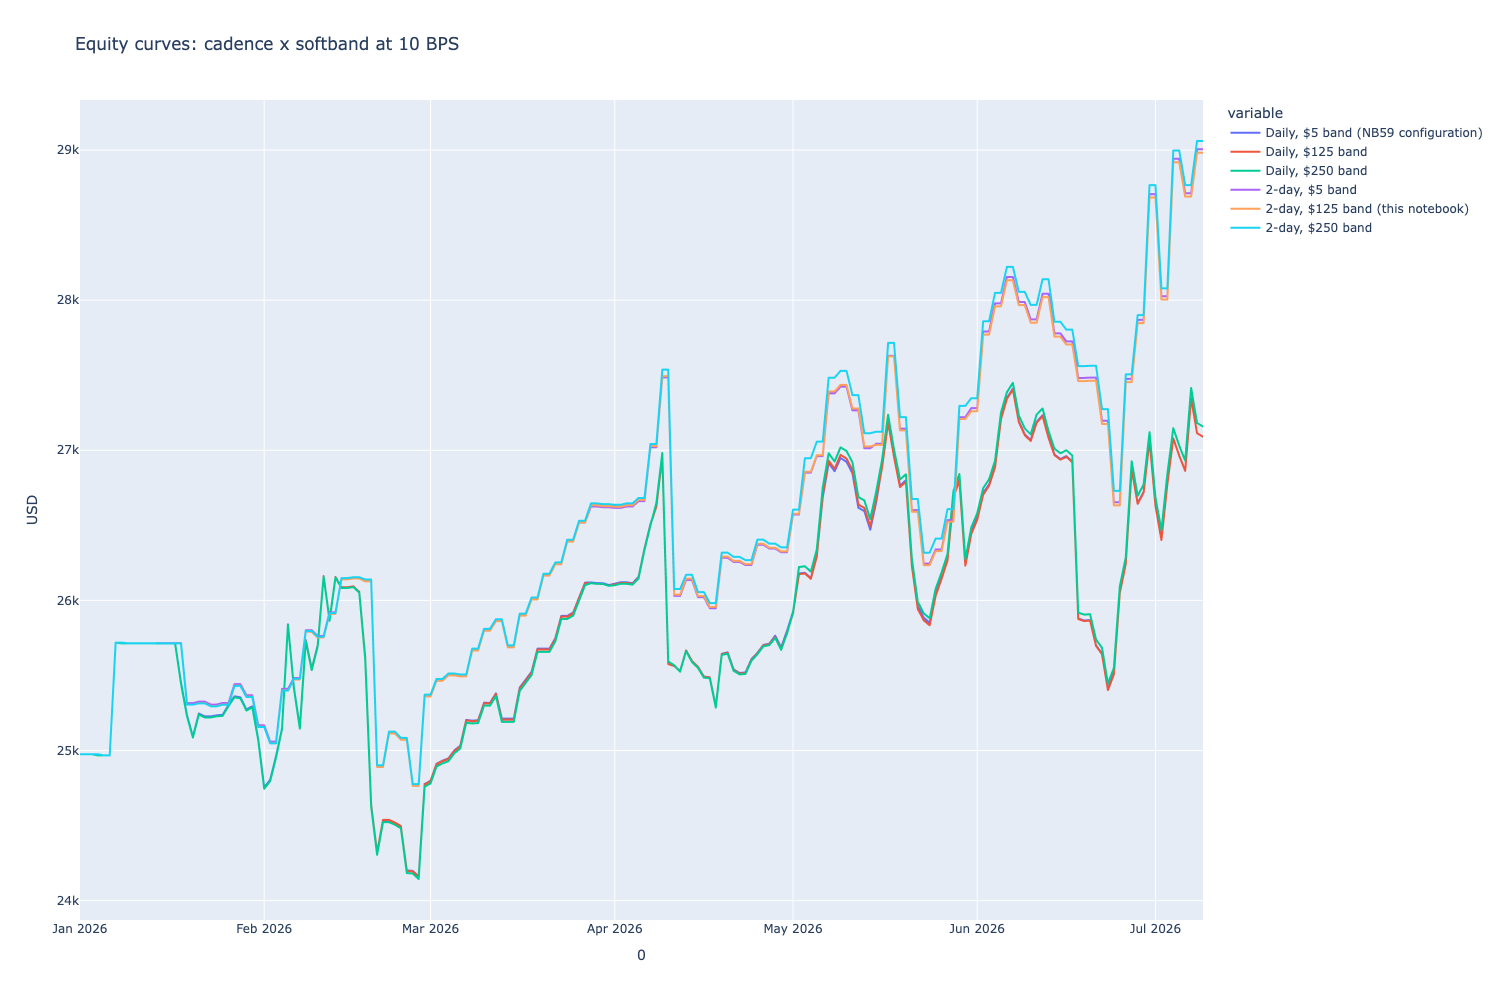

,CAGR delta,Drawdown delta,Trade delta,Fee delta
Comparison,,,,
"Cadence: daily -> 2-day, at the $5 band",+16.70%,+2.05%,-347,$-95
"Cadence: daily -> 2-day, at the $125 band",+16.50%,+2.06%,-209,$-92
"Cadence: daily -> 2-day, at the $250 band",+16.63%,+2.05%,-180,$-91
"Softband: $5 -> $125, at daily cadence",-0.00%,-0.01%,-229,$-5
"Softband: $5 -> $125, at 2-day cadence",-0.21%,+0.00%,-91,$-2
"Softband: $5 -> $250, at daily cadence",+0.57%,-0.05%,-290,$-8
"Softband: $5 -> $250, at 2-day cadence",+0.49%,-0.05%,-123,$-3
Both levers: daily/$5 -> 2-day/$125,+16.50%,+2.05%,-438,$-97


Full mitigation (daily/$5 -> 2-day/$125): CAGR +16.50%, fee saved $97 = 0.74%/yr of capital
Share of the CAGR change explained by the fee saving: 5%


In [21]:
from tradeexecutor.backtest.backtest_execution import BacktestExecutionFailed
from tradeexecutor.strategy.parameters import StrategyParameters

# One backtest per (cadence, softband) cell. Indicators do not depend on either lever, so the
# precomputed indicator combinations are reused and only the engine clock and the sell threshold
# change between runs.
def run_variant(label, cycle_duration, sell_threshold_usd, fee=Parameters.vault_redemption_fee,
                start_at=None, end_at=None, max_concentration_pct=None):
    """Run one configuration of the factorial and return its summary row plus its equity curve."""
    apply_vault_redemption_fee(strategy_universe, fee)
    run_parameters = StrategyParameters.from_dict(dict(parameters))
    run_parameters["cycle_duration"] = cycle_duration
    run_parameters["sell_rebalance_min_threshold_usd"] = sell_threshold_usd
    if max_concentration_pct is not None:
        run_parameters["max_concentration_pct"] = max_concentration_pct

    try:
        variant_result = run_backtest_inline(
            name=label,
            engine_version="0.5",
            decide_trades=decide_trades,
            indicator_combinations=indicator_data.indicator_combinations,
            cycle_duration=cycle_duration,
            client=client,
            universe=strategy_universe,
            parameters=run_parameters,
            max_workers=1,
            start_at=start_at or Parameters.backtest_start,
            end_at=end_at or Parameters.backtest_end,
        )
    except BacktestExecutionFailed as exc:
        # A wide softband can cancel a trim whose proceeds the rebalance plan had already
        # committed to a buy. Record the failure as a result: a configuration that cannot
        # complete a backtest cannot be a recommendation either.
        print(f"  {label}: CRASHED - {str(exc).splitlines()[0]}")
        return {"Run": label, "Crashed": True}, None

    variant_state = variant_result.state
    variant_equity = calculate_equity_curve(variant_state)

    sells = [
        t for t in variant_state.portfolio.get_all_trades()
        if t.pair.is_vault() and t.is_sell() and t.is_success()
    ]
    sell_volume = sum(abs(float(t.get_value() or 0.0)) for t in sells)
    exits = [t for t in sells if t.closing]

    row = summarise_run(label, variant_equity, variant_state)
    row.update({
        "Crashed": False,
        "Vault sells": len(sells),
        "Exits": len(exits),
        "Trims": len(sells) - len(exits),
        "Redemption volume": sell_volume,
        "Turnover x capital": sell_volume / Parameters.initial_cash,
        "Fee paid": sell_volume * fee / (1.0 - fee),
    })
    return row, variant_equity


FLOOR_BAND_USD = max(
    Parameters.absolute_min_vault_deposit_usd,
    Parameters.initial_cash * 0.0001,
)

factorial_specs = [
    ("Daily, $5 band (NB59 configuration)", CycleDuration.cycle_1d, FLOOR_BAND_USD),
    ("Daily, $125 band", CycleDuration.cycle_1d, 125.0),
    ("Daily, $250 band", CycleDuration.cycle_1d, 250.0),
    ("2-day, $5 band", CycleDuration.cycle_2d, FLOOR_BAND_USD),
    ("2-day, $125 band (this notebook)", CycleDuration.cycle_2d, 125.0),
    ("2-day, $250 band", CycleDuration.cycle_2d, 250.0),
]

factorial_rows = []
factorial_equities = {}
for spec_label, spec_cycle, spec_band in factorial_specs:
    print(f"Running {spec_label} ...")
    spec_row, spec_equity = run_variant(spec_label, spec_cycle, spec_band)
    factorial_rows.append(spec_row)
    if spec_equity is not None:
        factorial_equities[spec_label] = spec_equity

# Restore the configured fee so any later cell sees the fee-charging universe.
apply_vault_redemption_fee(strategy_universe, Parameters.vault_redemption_fee)

factorial_df = pd.DataFrame(factorial_rows).set_index("Run")
crashed_runs = factorial_df.index[factorial_df["Crashed"]].tolist()
if crashed_runs:
    print(f"{len(crashed_runs)} configuration(s) could not complete a backtest: {crashed_runs}")
factorial_df = factorial_df.drop(columns=["Crashed"])
display(factorial_df.style.format({
    "Final equity": "${:,.0f}",
    "Cumulative return": "{:.2%}",
    "CAGR": "{:.2%}",
    "Sharpe": "{:.2f}",
    "Sortino": "{:.2f}",
    "Max drawdown": "{:.2%}",
    "Positions": "{:.0f}",
    "Trades": "{:.0f}",
    "Vault sells": "{:.0f}",
    "Exits": "{:.0f}",
    "Trims": "{:.0f}",
    "Redemption volume": "${:,.0f}",
    "Turnover x capital": "{:.1f}x",
    "Fee paid": "${:,.0f}",
}).set_caption("Cadence x softband at 10 BPS, NB36 window (2025-08-01 to 2026-07-10)"))

fig = px.line(
    pd.DataFrame(factorial_equities).ffill(),
    title="Equity curves: cadence x softband at 10 BPS",
)
fig.update_yaxes(title="USD")
fig.show()

# Marginal effect of each lever, holding the other fixed. Comparisons involving a crashed
# configuration are skipped rather than silently dropped from the conclusion.
lookup = {row["Run"]: row for row in factorial_rows if not row.get("Crashed")}


def marginal(comparison, treated, control):
    if treated not in lookup or control not in lookup:
        print(f"Skipping '{comparison}': one side did not complete")
        return None
    return {
        "Comparison": comparison,
        "CAGR delta": lookup[treated]["CAGR"] - lookup[control]["CAGR"],
        "Drawdown delta": lookup[treated]["Max drawdown"] - lookup[control]["Max drawdown"],
        "Trade delta": lookup[treated]["Trades"] - lookup[control]["Trades"],
        "Fee delta": lookup[treated]["Fee paid"] - lookup[control]["Fee paid"],
    }


DAILY_5 = "Daily, $5 band (NB59 configuration)"
DAILY_125 = "Daily, $125 band"
DAILY_250 = "Daily, $250 band"
TWO_DAY_5 = "2-day, $5 band"
TWO_DAY_125 = "2-day, $125 band (this notebook)"
TWO_DAY_250 = "2-day, $250 band"

marginal_rows = [
    marginal("Cadence: daily -> 2-day, at the $5 band", TWO_DAY_5, DAILY_5),
    marginal("Cadence: daily -> 2-day, at the $125 band", TWO_DAY_125, DAILY_125),
    marginal("Cadence: daily -> 2-day, at the $250 band", TWO_DAY_250, DAILY_250),
    marginal("Softband: $5 -> $125, at daily cadence", DAILY_125, DAILY_5),
    marginal("Softband: $5 -> $125, at 2-day cadence", TWO_DAY_125, TWO_DAY_5),
    marginal("Softband: $5 -> $250, at daily cadence", DAILY_250, DAILY_5),
    marginal("Softband: $5 -> $250, at 2-day cadence", TWO_DAY_250, TWO_DAY_5),
    marginal("Both levers: daily/$5 -> 2-day/$125", TWO_DAY_125, DAILY_5),
]
marginals = pd.DataFrame([r for r in marginal_rows if r is not None]).set_index("Comparison")
display(marginals.style.format({
    "CAGR delta": "{:+.2%}",
    "Drawdown delta": "{:+.2%}",
    "Trade delta": "{:+.0f}",
    "Fee delta": "${:+,.0f}",
}).set_caption(
    "Marginal effect of each lever. A CAGR delta far larger than the fee delta means the lever "
    "is changing which vaults are held, not saving cost."
))

if TWO_DAY_125 in lookup and DAILY_5 in lookup:
    total_cagr = lookup[TWO_DAY_125]["CAGR"] - lookup[DAILY_5]["CAGR"]
    total_fee = lookup[DAILY_5]["Fee paid"] - lookup[TWO_DAY_125]["Fee paid"]
    window_years = (Parameters.backtest_end - Parameters.backtest_start).days / 365.0
    fee_cagr_equivalent = (total_fee / Parameters.initial_cash) / window_years
    print(
        f"Full mitigation (daily/$5 -> 2-day/$125): CAGR {total_cagr:+.2%}, "
        f"fee saved ${total_fee:,.0f} = {fee_cagr_equivalent:.2%}/yr of capital"
    )
    if abs(total_cagr) > 1e-9:
        print(f"Share of the CAGR change explained by the fee saving: {fee_cagr_equivalent / total_cagr:.0%}")


# Vault price data coverage

Every metric above assumes the daily candle series carries a daily price. It does not, for the first
half of this window. The scanner behind `vault-price-history.parquet` sampled Hypercore vaults
**weekly** until mid-January 2026 and daily afterwards, and `load_partial_data()` forward-fills the
gaps, so a stale price is indistinguishable from an unchanged one inside the backtest.

This cell measures it from the raw parquet rather than taking it on trust.


Measuring coverage for 326 vault pairs in the strategy universe


Chains represented: [9999]


,days,days_with_data,mean_vaults_reporting,Coverage
timestamp,,,,
2026-01-01 00:00:00,25,17,85,68%
2026-02-01 00:00:00,28,28,187,100%
2026-03-01 00:00:00,31,31,242,100%
2026-04-01 00:00:00,30,30,257,100%
2026-05-01 00:00:00,31,31,266,100%
2026-06-01 00:00:00,30,30,280,100%
2026-07-01 00:00:00,9,9,284,100%


Days in window: 184   days with no price data at all: 8 (4%)
Median gap between data days before 2026-01-17: 7 days
Median gap between data days after  2026-01-17: 1 days
Daily-resolution sub-window: 2026-01-17 to 2026-07-10


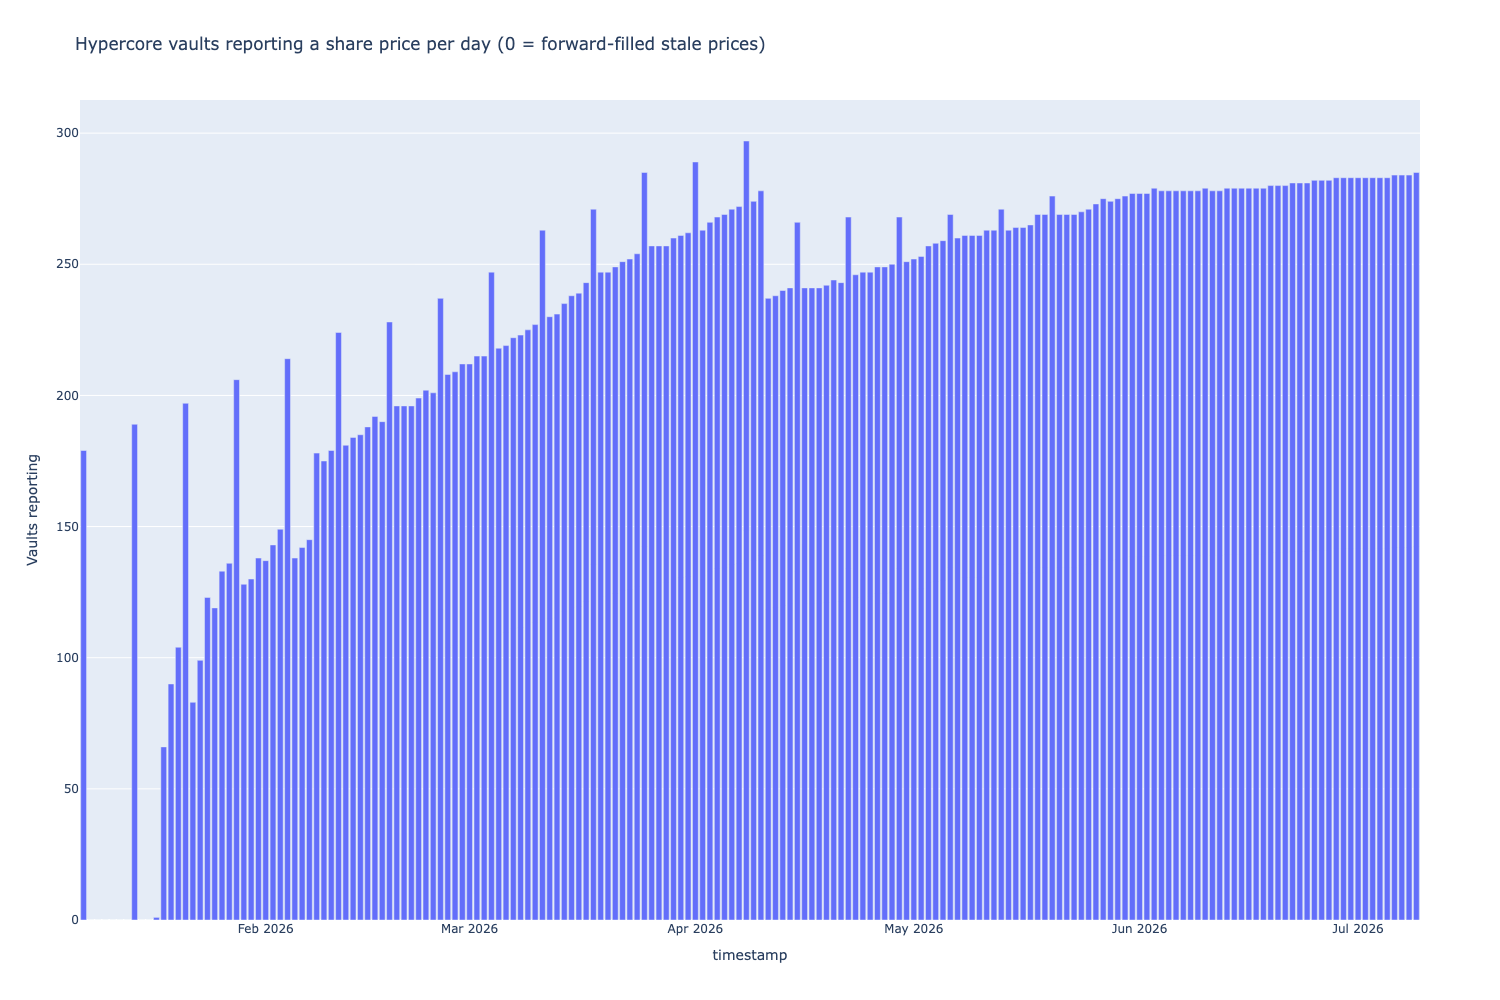

In [22]:
from pathlib import Path

VAULT_PRICE_PARQUET = Path.home() / ".cache/tradingstrategy/vaults/downloads/vault-price-history.parquet"

# Measure the vaults this strategy actually trades, identified by address.
#
# Do NOT filter on `CHAIN_ID`: it is `ChainId.hyperliquid` (999, HyperEVM), while the tradeable
# vaults are Hypercore vaults on chain 9999. Filtering on 999 selects a different, fully covered
# set of vaults and reports 0% missing data.
traded_vault_addresses = {
    pair.pool_address.lower()
    for pair in strategy_universe.iterate_pairs()
    if pair.is_vault() and pair.pool_address
}
print(f"Measuring coverage for {len(traded_vault_addresses)} vault pairs in the strategy universe")

# `timestamp` is the parquet index, not a column.
coverage_raw = pd.read_parquet(VAULT_PRICE_PARQUET, columns=["chain", "address"]).reset_index()
coverage_raw = coverage_raw[coverage_raw["address"].str.lower().isin(traded_vault_addresses)]
coverage_raw = coverage_raw[
    (coverage_raw["timestamp"] >= Parameters.backtest_start)
    & (coverage_raw["timestamp"] < Parameters.backtest_end)
]
print(f"Chains represented: {sorted(coverage_raw['chain'].unique().tolist())}")

vaults_per_day = coverage_raw.set_index("timestamp").resample("1D")["address"].nunique()

coverage_by_month = vaults_per_day.groupby(pd.Grouper(freq="MS")).agg(
    days="size",
    days_with_data=lambda s: int((s > 0).sum()),
    mean_vaults_reporting="mean",
)
coverage_by_month["Coverage"] = coverage_by_month["days_with_data"] / coverage_by_month["days"]
display(coverage_by_month.style.format({
    "mean_vaults_reporting": "{:.0f}",
    "Coverage": "{:.0%}",
}).set_caption("Days on which any Hypercore vault reported a share price"))

data_days = vaults_per_day[vaults_per_day > 0].index

# The first date from which coverage stays daily for at least a fortnight.
DAILY_DATA_START = None
for offset in range(len(data_days) - 14):
    window_gaps = pd.Series(data_days[offset:offset + 14]).diff().dt.days.fillna(1)
    if (window_gaps == 1).all():
        DAILY_DATA_START = data_days[offset]
        break

assert DAILY_DATA_START is not None, "Never found a fortnight of continuous daily coverage"
assert DAILY_DATA_START > Parameters.backtest_start, (
    f"Daily coverage starts at the window start ({DAILY_DATA_START}), so the sub-window test below "
    f"would just repeat the full window - check that the address filter selected the traded vaults"
)

blank_days = int((vaults_per_day == 0).sum())
print(f"Days in window: {len(vaults_per_day)}   days with no price data at all: {blank_days} ({blank_days/len(vaults_per_day):.0%})")
print(f"Median gap between data days before {DAILY_DATA_START.date()}: "
      f"{pd.Series(data_days[data_days < DAILY_DATA_START]).diff().dt.days.median():.0f} days")
print(f"Median gap between data days after  {DAILY_DATA_START.date()}: "
      f"{pd.Series(data_days[data_days >= DAILY_DATA_START]).diff().dt.days.median():.0f} days")
print(f"Daily-resolution sub-window: {DAILY_DATA_START.date()} to {Parameters.backtest_end.date()}")

fig = px.bar(
    vaults_per_day,
    title="Hypercore vaults reporting a share price per day (0 = forward-filled stale prices)",
)
fig.update_layout(showlegend=False)
fig.update_yaxes(title="Vaults reporting")
fig.show()


# The factorial repeated on daily-resolution data only

A cadence experiment cannot mean much where the underlying prices refresh weekly: rebalancing every
day and every two days both act on the same stale forward-filled number, and the strategy's returns
land in one lump on whichever day the feed resumes.

This repeats the factorial on the sub-window where the vault feed is genuinely daily. It is the
honest test of the 2-day cadence, at the cost of a shorter window. Indicator lookbacks still reach
back into the weekly-sampled period - only the traded window is restricted.


In [23]:
sub_specs = [
    ("Daily, $5 band", CycleDuration.cycle_1d, FLOOR_BAND_USD),
    ("Daily, $125 band", CycleDuration.cycle_1d, 125.0),
    ("2-day, $5 band", CycleDuration.cycle_2d, FLOOR_BAND_USD),
    ("2-day, $125 band", CycleDuration.cycle_2d, 125.0),
]

sub_rows = []
sub_equities = {}
for spec_label, spec_cycle, spec_band in sub_specs:
    print(f"Running {spec_label} on the daily-data sub-window ...")
    spec_row, spec_equity = run_variant(
        spec_label, spec_cycle, spec_band,
        start_at=DAILY_DATA_START.to_pydatetime(),
        end_at=Parameters.backtest_end,
    )
    sub_rows.append(spec_row)
    if spec_equity is not None:
        sub_equities[spec_label] = spec_equity

apply_vault_redemption_fee(strategy_universe, Parameters.vault_redemption_fee)

sub_df = pd.DataFrame(sub_rows).set_index("Run")
sub_crashed = sub_df.index[sub_df["Crashed"]].tolist()
if sub_crashed:
    print(f"{len(sub_crashed)} configuration(s) could not complete: {sub_crashed}")
sub_df = sub_df.drop(columns=["Crashed"])
display(sub_df.style.format({
    "Final equity": "${:,.0f}",
    "Cumulative return": "{:.2%}",
    "CAGR": "{:.2%}",
    "Sharpe": "{:.2f}",
    "Sortino": "{:.2f}",
    "Max drawdown": "{:.2%}",
    "Positions": "{:.0f}",
    "Trades": "{:.0f}",
    "Vault sells": "{:.0f}",
    "Exits": "{:.0f}",
    "Trims": "{:.0f}",
    "Redemption volume": "${:,.0f}",
    "Turnover x capital": "{:.1f}x",
    "Fee paid": "${:,.0f}",
}).set_caption(
    f"Cadence x softband at 10 BPS, daily-resolution sub-window "
    f"({DAILY_DATA_START.date()} to {Parameters.backtest_end.date()})"
))

sub_lookup = {row["Run"]: row for row in sub_rows if not row.get("Crashed")}
if "Daily, $5 band" in sub_lookup and "2-day, $5 band" in sub_lookup:
    full_effect = lookup[TWO_DAY_5]["CAGR"] - lookup[DAILY_5]["CAGR"]
    sub_effect = sub_lookup["2-day, $5 band"]["CAGR"] - sub_lookup["Daily, $5 band"]["CAGR"]
    print(f"Cadence effect (daily -> 2-day, $5 band):")
    print(f"  full window, half weekly-sampled data: {full_effect:+.2%} CAGR")
    print(f"  daily-resolution sub-window:           {sub_effect:+.2%} CAGR")

# Best-day concentration on each window: the weekly feed books a week of return in one print.
def best_day_share(equity_curve):
    daily_returns = calculate_returns(equity_curve).dropna()
    positive = daily_returns[daily_returns > 0]
    return daily_returns.max(), float(daily_returns.max() / positive.sum()), float(daily_returns.kurtosis())


for window_label, curve in (
    ("Full window (half weekly data)", factorial_equities.get(TWO_DAY_5)),
    ("Daily-resolution sub-window", sub_equities.get("2-day, $5 band")),
):
    if curve is None:
        continue
    best, share, kurt = best_day_share(curve)
    print(f"{window_label}: best day {best:.2%}, {share:.1%} of all positive daily return, excess kurtosis {kurt:.1f}")


Running Daily, $5 band on the daily-data sub-window ...


Running Daily, $125 band on the daily-data sub-window ...


Running 2-day, $5 band on the daily-data sub-window ...


Running 2-day, $125 band on the daily-data sub-window ...


,Final equity,Cumulative return,CAGR,Sharpe,Sortino,Max drawdown,Positions,Trades,Vault sells,Exits,Trims,Redemption volume,Turnover x capital,Fee paid
Run,,,,,,,,,,,,,,
"Daily, $5 band","$26,283",5.13%,11.37%,0.67,0.89,-7.64%,81,831,405,75,330,"$379,839",15.2x,$380
"Daily, $125 band","$26,298",5.19%,11.50%,0.68,0.89,-7.65%,81,605,226,75,151,"$375,258",15.0x,$376
"2-day, $5 band","$28,120",12.48%,28.61%,1.48,2.05,-5.63%,68,488,232,62,170,"$288,168",11.5x,$288
"2-day, $125 band","$28,092",12.37%,28.35%,1.47,2.04,-5.62%,68,400,160,62,98,"$286,432",11.5x,$287


Cadence effect (daily -> 2-day, $5 band):
  full window, half weekly-sampled data: +16.70% CAGR
  daily-resolution sub-window:           +17.24% CAGR
Full window (half weekly data): best day 3.27%, 6.8% of all positive daily return, excess kurtosis 4.6
Daily-resolution sub-window: best day 3.23%, 7.2% of all positive daily return, excess kurtosis 4.6


# Why this differs from the NB63 / NB64 optimiser search

This notebook now shares NB63/NB64's window, so the remaining differences are the concentration
ceiling and the mechanics. This cell measures the sensitivity to each rather than assuming it.

- **Concentration ceiling** - 0.33 here, 0.35 in NB63/NB64, 0.50 in NB36. An earlier revision of
  this notebook measured 0.50 -> 0.35 as worth +5.25 pp of CAGR, so the axis is steep and it is
  worth knowing whether 0.33 and 0.35 differ materially.
- **The 55%-covered fortnight** - 2026-01-01 to 2026-01-17 trades partly on forward-filled prices.
  Re-running from 2026-01-17 shows how much of the result depends on it.

Two differences remain outside this notebook's control and show up in the residual:

- **Dataset vintage** - NB63/NB64 read an isolated copy of `hl-min-1000` frozen at 13:41 on
  2026-08-08 (202,154,321 bytes). This notebook reads the shared cache, re-downloaded at 17:33 the
  same day (202,297,246 bytes, 143 KB larger).
- **Cadence mechanism** - NB64 reached 48h by stepping a 2h clock and skipping 23 of every 24
  cycles; this notebook steps natively every 2 days. An earlier revision measured these two
  together at 0.14 pp of CAGR, i.e. negligible.


In [24]:
attribution_specs = [
    ("This notebook: 33% cap, from 2026-01-01", 0.33, Parameters.backtest_start),
    ("NB63/NB64 cap: 35% cap, from 2026-01-01", 0.35, Parameters.backtest_start),
    ("NB36 cap: 50% cap, from 2026-01-01", 0.50, Parameters.backtest_start),
    ("Daily data only: 33% cap, from 2026-01-17", 0.33, DAILY_DATA_START.to_pydatetime()),
]

attribution_rows = []
for spec_label, spec_conc, spec_start in attribution_specs:
    print(f"Running {spec_label} ...")
    spec_row, _ = run_variant(
        spec_label,
        CycleDuration.cycle_2d,
        FLOOR_BAND_USD,
        start_at=spec_start,
        end_at=Parameters.backtest_end,
        max_concentration_pct=spec_conc,
    )
    spec_row["Concentration"] = spec_conc
    spec_row["Start"] = spec_start.date()
    attribution_rows.append(spec_row)

apply_vault_redemption_fee(strategy_universe, Parameters.vault_redemption_fee)

attribution_df = pd.DataFrame(attribution_rows).set_index("Run")
attribution_df = attribution_df.drop(columns=["Crashed"])
display(attribution_df[[
    "Concentration", "Start", "Final equity", "Cumulative return", "CAGR",
    "Sharpe", "Max drawdown", "Positions", "Trades",
]].style.format({
    "Concentration": "{:.0%}",
    "Final equity": "${:,.0f}",
    "Cumulative return": "{:.2%}",
    "CAGR": "{:.2%}",
    "Sharpe": "{:.2f}",
    "Max drawdown": "{:.2%}",
    "Positions": "{:.0f}",
    "Trades": "{:.0f}",
}).set_caption("Reconciling this notebook with the NB63/NB64 optimiser search, 2-day cadence, $5 band, 10 BPS"))

attr = {row["Run"]: row for row in attribution_rows}
base = attr["This notebook: 33% cap, from 2026-01-01"]["CAGR"]
cap_35 = attr["NB63/NB64 cap: 35% cap, from 2026-01-01"]["CAGR"]
cap_50 = attr["NB36 cap: 50% cap, from 2026-01-01"]["CAGR"]
daily_only = attr["Daily data only: 33% cap, from 2026-01-17"]["CAGR"]

print(f"\nCAGR sensitivity around this notebook's {base:.2%} baseline:")
print(f"  concentration 33% -> 35% (NB63/NB64):  {cap_35 - base:+.2%}")
print(f"  concentration 33% -> 50% (NB36):       {cap_50 - base:+.2%}")
print(f"  dropping the 55%-covered fortnight:    {daily_only - base:+.2%}")

# NB64 measured 33.45% for exactly this schedule and band at a 35% cap over the same window.
NB64_48H_HOLD1_BAND5 = 0.3345
print(f"\nNB64's 48h / hold 1 / $5 band at a 35% cap over the same window: {NB64_48H_HOLD1_BAND5:.2%}")
print(f"This notebook at a 35% cap: {cap_35:.2%}. Residual: {cap_35 - NB64_48H_HOLD1_BAND5:+.2%}")
print("The residual covers only the dataset vintage and the cadence mechanism "
      "(native cycle_2d here, 2h clock with a modulo counter in NB64).")


Running This notebook: 33% cap, from 2026-01-01 ...


Running NB63/NB64 cap: 35% cap, from 2026-01-01 ...


Running NB36 cap: 50% cap, from 2026-01-01 ...


Running Daily data only: 33% cap, from 2026-01-17 ...


,Concentration,Start,Final equity,Cumulative return,CAGR,Sharpe,Max drawdown,Positions,Trades
Run,,,,,,,,,
"This notebook: 33% cap, from 2026-01-01",33%,2026-01-01,"$29,005",16.02%,33.70%,1.72,-5.60%,70,511
"NB63/NB64 cap: 35% cap, from 2026-01-01",35%,2026-01-01,"$29,018",16.07%,33.81%,1.75,-5.90%,70,514
"NB36 cap: 50% cap, from 2026-01-01",50%,2026-01-01,"$28,452",13.81%,28.79%,1.70,-6.07%,70,523
"Daily data only: 33% cap, from 2026-01-17",33%,2026-01-17,"$28,120",12.48%,28.61%,1.48,-5.63%,68,488



CAGR sensitivity around this notebook's 33.70% baseline:
  concentration 33% -> 35% (NB63/NB64):  +0.11%
  concentration 33% -> 50% (NB36):       -4.91%
  dropping the 55%-covered fortnight:    -5.09%

NB64's 48h / hold 1 / $5 band at a 35% cap over the same window: 33.45%
This notebook at a 35% cap: 33.81%. Residual: +0.36%
The residual covers only the dataset vintage and the cadence mechanism (native cycle_2d here, 2h clock with a modulo counter in NB64).


# Robustness diagnostics

In [25]:
from tradeexecutor.statistics.key_metric import (
    calculate_cagr,
    calculate_max_drawdown,
    calculate_sharpe,
    calculate_sortino,
)
from tradeexecutor.curator import is_quarantined


def return_metrics(return_series: pd.Series) -> dict:
    return_series = return_series.dropna()
    cagr = float(calculate_cagr(return_series))
    max_drawdown = float(calculate_max_drawdown(return_series))
    return {
        'Cumulative return': float((1.0 + return_series).prod() - 1.0),
        'CAGR': cagr,
        'Sharpe': float(calculate_sharpe(return_series, periods=365)),
        'Sortino': float(calculate_sortino(return_series, periods=365)),
        'Max drawdown': max_drawdown,
    }


daily_returns = calculate_returns(equity).resample('1D').sum(min_count=1).fillna(0.0)
profitable_returns = daily_returns[daily_returns > 0.0]
profitable_outlier_cutoff = profitable_returns.quantile(0.95)
profitable_outlier_mask = (daily_returns > 0.0) & (daily_returns > profitable_outlier_cutoff)
returns_without_best_days = daily_returns.mask(profitable_outlier_mask, 0.0)

robustness_df = pd.DataFrame([
    {'Scenario': 'Original', **return_metrics(daily_returns)},
    {
        'Scenario': 'Largest 5% profitable daily returns neutralised',
        **return_metrics(returns_without_best_days),
    },
]).set_index('Scenario')
display(robustness_df.style.format({
    'Cumulative return': '{:.2%}',
    'CAGR': '{:.2%}',
    'Sharpe': '{:.2f}',
    'Sortino': '{:.2f}',
    'Max drawdown': '{:.2%}',
}))

best_day = pd.Timestamp(daily_returns.idxmax()).normalize()
daily_return_diagnostics_df = pd.DataFrame([{
    'Best day': best_day,
    'Best-day return': float(daily_returns.max()),
    'Worst day': pd.Timestamp(daily_returns.idxmin()).normalize(),
    'Worst-day return': float(daily_returns.min()),
    'Best-day share of positive daily returns': float(daily_returns.max() / profitable_returns.sum()),
    'Daily-return skew': float(daily_returns.skew()),
    'Daily excess kurtosis': float(daily_returns.kurtosis()),
    'Neutralised profitable days': int(profitable_outlier_mask.sum()),
    'Neutralisation cutoff': float(profitable_outlier_cutoff),
}])
display(daily_return_diagnostics_df.style.format({
    'Best-day return': '{:.2%}',
    'Worst-day return': '{:.2%}',
    'Best-day share of positive daily returns': '{:.1%}',
    'Daily-return skew': '{:.2f}',
    'Daily excess kurtosis': '{:.2f}',
    'Neutralisation cutoff': '{:.2%}',
}))

valuation_rows = []
for position in positions:
    for update in position.valuation_updates:
        valuation_day = pd.Timestamp(update.valued_at).normalize()
        if valuation_day != best_day or update.old_value is None:
            continue
        valuation_rows.append({
            'Vault': position.pair.base.token_symbol,
            'Vault address': position.pair.pool_address,
            'Valuation change USD': float(update.new_value - update.old_value),
            'Curator-quarantined on best day': is_quarantined(
                position.pair.pool_address,
                best_day.to_pydatetime(),
            ),
        })

best_day_valuation_df = pd.DataFrame(valuation_rows)
if len(best_day_valuation_df):
    best_day_valuation_df = best_day_valuation_df.sort_values('Valuation change USD', ascending=False)
display(best_day_valuation_df.head(12).style.format({'Valuation change USD': '${:,.0f}'}))



from tradeexecutor.curator.curator import QUARANTINE_PERIODS

quarantine_overlap_rows = []
for position in positions:
    position_address = position.pair.pool_address.lower()
    position_end = position.closed_at or Parameters.backtest_end
    for address, quarantine_start, quarantine_end, reason in QUARANTINE_PERIODS:
        if position_address != address.lower():
            continue
        if position.opened_at <= quarantine_end and position_end >= quarantine_start:
            quarantine_overlap_rows.append({
                'Vault': position.pair.base.token_symbol,
                'Opened': position.opened_at,
                'Closed': position.closed_at,
                'Quarantine start': quarantine_start,
                'Quarantine end': quarantine_end,
                'Realised profit USD': float(position.get_realised_profit_usd() or 0.0),
                'Reason': reason,
            })

quarantine_overlap_df = pd.DataFrame(quarantine_overlap_rows)
display(quarantine_overlap_df.style.format({'Realised profit USD': '${:,.0f}'}).set_caption('Curator quarantine overlap audit'))



best_day_position_rows = []
for position in positions:
    position_end = position.closed_at or Parameters.backtest_end
    if not (position.opened_at <= best_day.to_pydatetime() <= position_end):
        continue
    candles = strategy_universe.data_universe.candles.get_candles_by_pair(position.pair.internal_id)
    candle_closes = candles.set_index('timestamp')['close'].sort_index()
    # The equity curve is sampled once per strategy cycle, so on a 2-day cadence the "best day"
    # booked a two-day move. Measure each vault over the same span - comparing against yesterday's
    # close attributes only the final day and can show every holding flat while the portfolio jumps.
    equity_sample_days = pd.DatetimeIndex(equity.index).normalize()
    earlier_samples = equity_sample_days[equity_sample_days < best_day]
    span_start = earlier_samples[-1] if len(earlier_samples) else best_day - pd.Timedelta(days=1)
    close_on_best_day = candle_closes.loc[candle_closes.index <= best_day].iloc[-1]
    close_before_best_day = candle_closes.loc[candle_closes.index <= span_start].iloc[-1]
    best_day_position_rows.append({
        'Vault': position.pair.base.token_symbol,
        'Position opened': position.opened_at,
        'Position closed': position.closed_at,
        'Vault return over the best step': float(close_on_best_day / close_before_best_day - 1.0),
        'Realised profit USD': float(position.get_realised_profit_usd() or 0.0),
        'Curator-quarantined on best day': is_quarantined(
            position.pair.pool_address,
            best_day.to_pydatetime(),
        ),
    })

best_day_positions_df = pd.DataFrame(best_day_position_rows).sort_values(
    'Vault return over the best step',
    ascending=False,
)
display(
    best_day_positions_df.style.format({
        'Vault return over the best step': '{:.2%}',
        'Realised profit USD': '${:,.0f}',
    }).set_caption('Position moves on the best portfolio day')
)


,Cumulative return,CAGR,Sharpe,Sortino,Max drawdown
Scenario,,,,,
Original,16.04%,33.49%,1.70,2.44,-5.60%
Largest 5% profitable daily returns neutralised,5.83%,11.62%,0.76,0.99,-5.60%


,Best day,Best-day return,Worst day,Worst-day return,Best-day share of positive daily returns,Daily-return skew,Daily excess kurtosis,Neutralised profitable days,Neutralisation cutoff
0,2026-07-04 00:00:00,3.27%,2026-04-11 00:00:00,-5.30%,6.8%,-0.98,11.11,3,3.01%


,Vault,Position opened,Position closed,Vault return over the best step,Realised profit USD,Curator-quarantined on best day
2,Realist Ca,2026-06-24 00:00:00,NaT,4.02%,$386,False
3,Scared Mon,2026-07-02 00:00:00,NaT,3.79%,$126,False
1,Mad Scient,2026-06-22 00:00:00,NaT,3.68%,$35,False
4,DOEZOE,2026-06-30 00:00:00,2026-07-04 00:00:00,1.51%,$-8,False
5,pmalt,2026-07-04 00:00:00,2026-07-06 00:00:00,0.99%,$-3,False
6,Citadel,2026-06-24 00:00:00,2026-07-08 00:00:00,0.00%,$-10,False
0,Goon Edgin,2026-06-20 00:00:00,NaT,-3.32%,$166,False
